## Qualitative Evaluation Summary

### 1. End-to-End Pipeline

The proposed pipeline consists of the following stages:

1. **Image Loading:** H-alpha images are loaded as grayscale images.
2. **Ground-Truth Mask Generation:** Polygon annotations are converted into binary segmentation masks.
3. **Preprocessing:** Images and masks are resized to **512 × 512** pixels, and image intensities are normalized to the **[0, 1]** range.
4. **Model Training:** A **U-Net** model is trained to perform binary segmentation of solar filaments.
5. **Probability Prediction:** The trained model outputs a pixel-wise filament probability map.
6. **Threshold Optimization:** An optimized probability threshold is applied to convert probability maps into binary predictions.
7. **Post-processing:** Small predicted components are removed using an optimized minimum-area threshold.
8. **Instance Extraction:** Connected components are used to separate individual predicted filament instances.
9. **Instance Matching:** Predicted instances are matched with ground-truth instances using IoU-based one-to-one matching.
10. **Evaluation:** Panoptic Quality (PQ), Dice, IoU, and one-to-many and many-to-one relations are evaluated on the validation set.
11. **Final Model Training:** The U-Net model is retrained using the complete training dataset.
12. **Test Inference:** The final model is applied only to the provided test H-alpha images to generate filament predictions.
13. **Submission Generation:** Predicted filament instances are encoded using COCO RLE and saved in the required submission format.

### 2. Model Architecture

The segmentation model is a **U-Net architecture** consisting of an encoder, bottleneck, decoder, and skip connections. The model receives a single-channel H-alpha image as input and produces a single-channel pixel-wise probability map representing the likelihood of each pixel belonging to a solar filament.

### 3. Morphology Evaluation

Representative validation cases are visualized using the original H-alpha image, ground-truth mask, binary prediction, predicted instances, and prediction overlay. These visualizations are used to qualitatively assess whether the predicted filament structures follow the apparent morphology and spatial characteristics of solar filaments observed in the H-alpha images.

The error analysis includes representative cases with the **worst PQ, best PQ, most false positives, and most false negatives** to examine different prediction behaviors and segmentation errors.

### 4. Code Quality and Reproducibility

The notebook is organized into modular stages covering data preparation, model definition, training, evaluation, post-processing, error analysis, final inference, and submission generation.

Reusable functions are implemented for:

- Ground-truth mask creation
- Connected-component extraction
- Instance matching
- IoU, Dice, and PQ calculation
- Validation visualization
- RLE encoding

Configuration parameters, final validation results, and model outputs are also saved to support reproducibility and clear documentation of the final pipeline.

# Imports & Configuration

In [1]:
# ============================================
# 01. IMPORTS + CONFIGURATION
# ============================================

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split


# ============================================
# RANDOM SEED
# ============================================

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================
# CONFIGURATION
# ============================================

IMAGE_SIZE = 512
BATCH_SIZE = 8
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4

# Initial segmentation threshold
DEFAULT_THRESHOLD = 0.50

# Initial minimum component area
DEFAULT_MIN_AREA = 25


print("Configuration:")
print(f"Image size: {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Random seed: {SEED}")

Configuration:
Image size: 512 × 512
Batch size: 8
Epochs: 15
Learning rate: 0.0001
Random seed: 42


# Dataset Setup & File Checks

In [2]:
# ============================================
# 02. DATASET SETUP + FILE CHECKS
# ============================================

INPUT_DIR = Path("/kaggle/input")

# Competition dataset
DATA_DIR = (
    INPUT_DIR
    / "competitions"
    / "filament-segmentation-2026"
    / "MAGFiLO_1.0_Kaggle_2026"
)

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

TRAIN_IMAGES_DIR = TRAIN_DIR / "train_images"
TEST_IMAGES_DIR = TEST_DIR / "test_images"

ANNOTATION_FILE = (
    TRAIN_DIR
    / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"
)


# ============================================
# FIND IMAGES
# ============================================

train_images = sorted(TRAIN_IMAGES_DIR.glob("*.jpeg"))
test_images = sorted(TEST_IMAGES_DIR.glob("*.jpeg"))


# ============================================
# DISPLAY DATASET INFORMATION
# ============================================

print("============================================")
print("DATASET INFORMATION")
print("============================================")

print(f"Training images : {len(train_images)}")
print(f"Test images     : {len(test_images)}")
print(f"Annotations     : {ANNOTATION_FILE.exists()}")


# ============================================
# PATH CHECKS
# ============================================

print("\n============================================")
print("PATH CHECKS")
print("============================================")

print(f"Train directory exists : {TRAIN_IMAGES_DIR.exists()}")
print(f"Test directory exists  : {TEST_IMAGES_DIR.exists()}")
print(f"Annotation file exists : {ANNOTATION_FILE.exists()}")


# ============================================
# SAMPLE FILES
# ============================================

print("\n============================================")
print("SAMPLE FILES")
print("============================================")

if train_images:
    print("Training:", train_images[0].name)

if test_images:
    print("Test:", test_images[0].name)

DATASET INFORMATION
Training images : 707
Test images     : 180
Annotations     : True

PATH CHECKS
Train directory exists : True
Test directory exists  : True
Annotation file exists : True

SAMPLE FILES
Training: 20110109104734Ch.jpeg
Test: 20110120105534Ch.jpeg


# Annotation Loading & EDA

ANNOTATION INFORMATION
Number of image records      : 1154
Number of annotation records : 8199

FILAMENT STATISTICS
count    1154.000000
mean        7.104853
std         4.375513
min         1.000000
25%         4.000000
50%         7.000000
75%        10.000000
max        26.000000
Name: num_filaments, dtype: float64


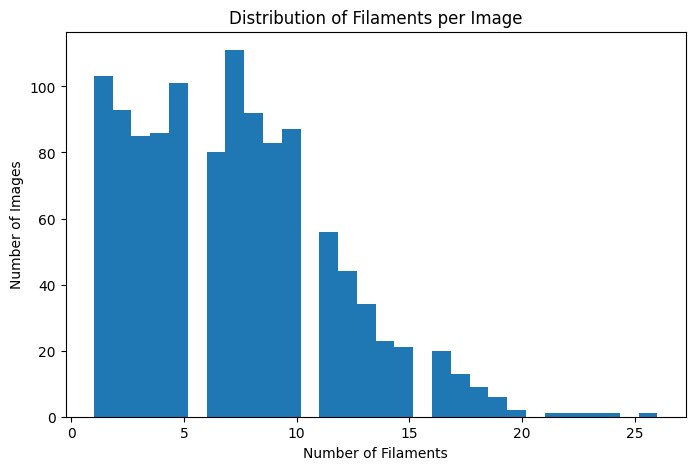

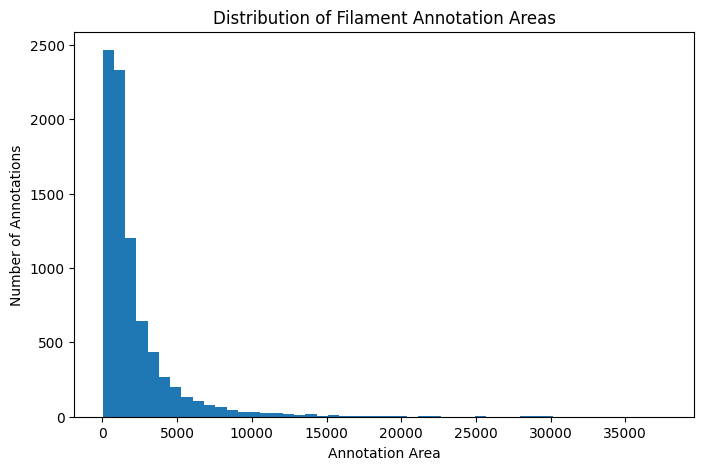


DATA CONSISTENCY
Training images without annotations : 0
Annotations without image files     : 0


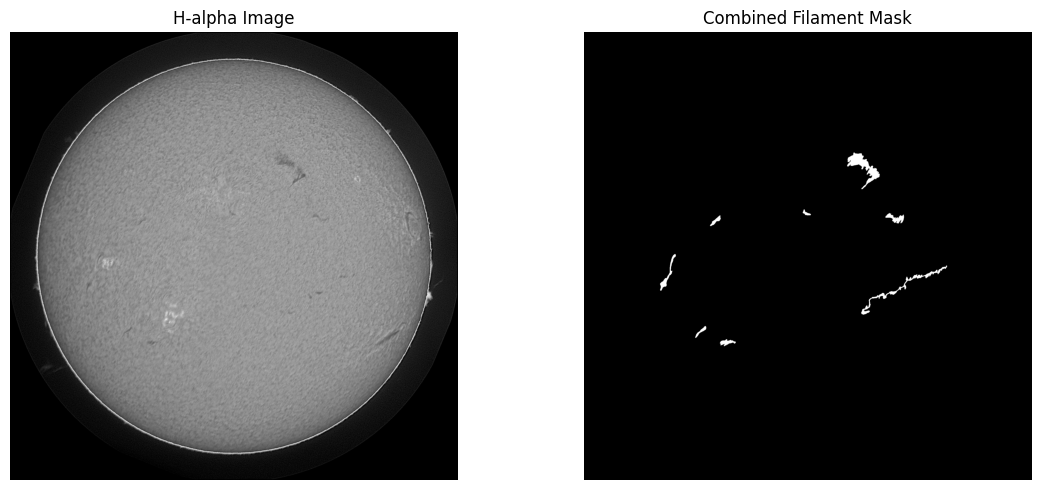


Sample image:
20160225173314Mh.jpeg
Number of annotated filaments: 8


In [3]:
# ============================================
# 03. ANNOTATION LOADING + EDA
# ============================================

# ============================================
# LOAD COCO-STYLE ANNOTATIONS
# ============================================

with open(ANNOTATION_FILE, "r") as f:
    annotations_data = json.load(f)


# ============================================
# BASIC ANNOTATION STRUCTURE
# ============================================

images_info = annotations_data.get("images", [])
annotations = annotations_data.get("annotations", [])

print("============================================")
print("ANNOTATION INFORMATION")
print("============================================")

print(f"Number of image records      : {len(images_info)}")
print(f"Number of annotation records : {len(annotations)}")


# ============================================
# CREATE LOOKUP DICTIONARIES
# ============================================

image_info = {
    img["id"]: img
    for img in images_info
}

image_annotations = {}

for ann in annotations:
    image_id = ann["image_id"]

    if image_id not in image_annotations:
        image_annotations[image_id] = []

    image_annotations[image_id].append(ann)


# ============================================
# CREATE FILENAME → ANNOTATIONS MAPPING
# ============================================

filename_to_annotations = {}

for image_id, anns in image_annotations.items():

    if image_id not in image_info:
        continue

    filename = image_info[image_id]["file_name"]

    filename_to_annotations[filename] = anns


# ============================================
# FILAMENT COUNT DATAFRAME
# ============================================

filament_records = []

for image_id, img_info in image_info.items():

    filename = img_info["file_name"]

    anns = image_annotations.get(image_id, [])

    filament_records.append({
        "image_id": image_id,
        "filename": filename,
        "num_filaments": len(anns)
    })


filament_df = pd.DataFrame(filament_records)


# ============================================
# BASIC STATISTICS
# ============================================

print("\n============================================")
print("FILAMENT STATISTICS")
print("============================================")

print(
    filament_df["num_filaments"].describe()
)


# ============================================
# FILAMENT COUNT DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

plt.hist(
    filament_df["num_filaments"],
    bins=30
)

plt.xlabel("Number of Filaments")
plt.ylabel("Number of Images")
plt.title("Distribution of Filaments per Image")

plt.show()


# ============================================
# ANNOTATION AREA DISTRIBUTION
# ============================================

annotation_areas = []

for ann in annotations:

    area = ann.get("area", None)

    if area is not None:
        annotation_areas.append(area)


if annotation_areas:

    plt.figure(figsize=(8, 5))

    plt.hist(
        annotation_areas,
        bins=50
    )

    plt.xlabel("Annotation Area")
    plt.ylabel("Number of Annotations")
    plt.title("Distribution of Filament Annotation Areas")

    plt.show()


# ============================================
# DATA CONSISTENCY CHECK
# ============================================

train_filenames = {
    path.name
    for path in train_images
}

annotation_filenames = set(
    filename_to_annotations.keys()
)

missing_annotations = (
    train_filenames - annotation_filenames
)

missing_images = (
    annotation_filenames - train_filenames
)

print("\n============================================")
print("DATA CONSISTENCY")
print("============================================")

print(
    f"Training images without annotations : "
    f"{len(missing_annotations)}"
)

print(
    f"Annotations without image files     : "
    f"{len(missing_images)}"
)


# ============================================
# SAMPLE IMAGE VISUALIZATION
# ============================================

sample_filename = None

for filename in train_filenames:

    if filename in filename_to_annotations:
        sample_filename = filename
        break


if sample_filename is not None:

    sample_path = TRAIN_IMAGES_DIR / sample_filename

    image = Image.open(sample_path).convert("L")

    sample_mask = Image.new(
        "L",
        image.size,
        0
    )

    draw = ImageDraw.Draw(sample_mask)

    for ann in filename_to_annotations[sample_filename]:

        segmentation = ann.get(
            "segmentation",
            []
        )

        for polygon in segmentation:

            if len(polygon) >= 6:

                points = [
                    (
                        polygon[i],
                        polygon[i + 1]
                    )
                    for i in range(
                        0,
                        len(polygon),
                        2
                    )
                ]

                draw.polygon(
                    points,
                    fill=1
                )


    # Convert to arrays
    image_array = np.array(image)
    mask_array = np.array(sample_mask)


    # ========================================
    # VISUALIZE
    # ========================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5)
    )

    axes[0].imshow(
        image_array,
        cmap="gray"
    )

    axes[0].set_title("H-alpha Image")
    axes[0].axis("off")


    axes[1].imshow(
        mask_array,
        cmap="gray"
    )

    axes[1].set_title("Combined Filament Mask")
    axes[1].axis("off")


    plt.tight_layout()
    plt.show()


    print("\nSample image:")
    print(sample_filename)

    print(
        "Number of annotated filaments:",
        len(filename_to_annotations[sample_filename])
    )

# Train/Validation Split & Dataset

In [5]:
# ============================================
# 04. TRAIN/VALIDATION SPLIT + DATASET
# ============================================

# ============================================
# IMAGE FILENAMES
# ============================================

all_filenames = sorted([
    path.name
    for path in train_images
])


# ============================================
# TRAIN / VALIDATION SPLIT
# ============================================

train_names, val_names = train_test_split(
    all_filenames,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)


print("============================================")
print("TRAIN / VALIDATION SPLIT")
print("============================================")

print(f"Total images      : {len(all_filenames)}")
print(f"Training images   : {len(train_names)}")
print(f"Validation images : {len(val_names)}")


# ============================================
# BINARY MASK CREATION
# ============================================

def create_binary_mask(
    filename,
    image_size=(2048, 2048)
):

    mask = Image.new(
        "L",
        image_size,
        0
    )

    draw = ImageDraw.Draw(mask)

    anns = filename_to_annotations.get(
        filename,
        []
    )

    for ann in anns:

        segmentation = ann.get(
            "segmentation",
            []
        )

        for polygon in segmentation:

            if len(polygon) < 6:
                continue

            points = [
                (
                    polygon[i],
                    polygon[i + 1]
                )
                for i in range(
                    0,
                    len(polygon),
                    2
                )
            ]

            draw.polygon(
                points,
                fill=1
            )

    return np.array(mask, dtype=np.float32)


# ============================================
# DATASET CLASS
# ============================================

class FilamentDataset(Dataset):

    def __init__(
        self,
        filenames,
        image_dir,
        image_size=512
    ):

        self.filenames = filenames
        self.image_dir = Path(image_dir)
        self.image_size = image_size


    def __len__(self):

        return len(self.filenames)


    def __getitem__(self, idx):

        filename = self.filenames[idx]

        image_path = (
            self.image_dir / filename
        )


        # ----------------------------------------
        # LOAD IMAGE
        # ----------------------------------------

        image = Image.open(
            image_path
        ).convert("L")


        # ----------------------------------------
        # CREATE ORIGINAL-SIZE MASK
        # ----------------------------------------

        mask = create_binary_mask(
            filename,
            image_size=image.size
        )


        mask = Image.fromarray(
            mask,
        )


        # ----------------------------------------
        # RESIZE
        # ----------------------------------------

        image = image.resize(
            (
                self.image_size,
                self.image_size
            ),
            Image.Resampling.BILINEAR
        )

        mask = mask.resize(
            (
                self.image_size,
                self.image_size
            ),
            Image.Resampling.NEAREST
        )


        # ----------------------------------------
        # CONVERT TO NUMPY
        # ----------------------------------------

        image = np.asarray(
            image,
            dtype=np.float32
        ) / 255.0

        mask = np.asarray(
            mask,
            dtype=np.float32
        )


        # ----------------------------------------
        # ADD CHANNEL DIMENSION
        # ----------------------------------------

        image = np.expand_dims(
            image,
            axis=0
        )

        mask = np.expand_dims(
            mask,
            axis=0
        )


        # ----------------------------------------
        # CONVERT TO TENSOR
        # ----------------------------------------

        image = torch.from_numpy(
            image
        )

        mask = torch.from_numpy(
            mask
        )


        return image, mask


# ============================================
# CREATE DATASETS
# ============================================

train_dataset = FilamentDataset(
    filenames=train_names,
    image_dir=TRAIN_IMAGES_DIR,
    image_size=IMAGE_SIZE
)

val_dataset = FilamentDataset(
    filenames=val_names,
    image_dir=TRAIN_IMAGES_DIR,
    image_size=IMAGE_SIZE
)


# ============================================
# SANITY CHECK
# ============================================

sample_image, sample_mask = train_dataset[0]

print("\n============================================")
print("DATASET SANITY CHECK")
print("============================================")

print("Image shape :", sample_image.shape)
print("Mask shape  :", sample_mask.shape)

print(
    "Image range :",
    sample_image.min().item(),
    "to",
    sample_image.max().item()
)

print(
    "Mask values :",
    torch.unique(sample_mask)
)

TRAIN / VALIDATION SPLIT
Total images      : 707
Training images   : 565
Validation images : 142

DATASET SANITY CHECK
Image shape : torch.Size([1, 512, 512])
Mask shape  : torch.Size([1, 512, 512])
Image range : 0.0 to 0.7843137383460999
Mask values : tensor([0., 1.])


# DataLoader & Device

In [6]:
# ============================================
# 05. DATALOADER + DEVICE
# ============================================

# ============================================
# DATALOADERS
# ============================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ============================================
# DEVICE
# ============================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================
# DISPLAY INFORMATION
# ============================================

print("============================================")
print("DATALOADER + DEVICE")
print("============================================")

print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")

print(f"\nDevice: {device}")


if torch.cuda.is_available():

    print(
        f"GPU: {torch.cuda.get_device_name(0)}"
    )

    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3
    )

    print(
        f"GPU memory: {gpu_memory:.2f} GB"
    )


# ============================================
# BATCH SANITY CHECK
# ============================================

images, masks = next(iter(train_loader))

print("\n============================================")
print("BATCH SANITY CHECK")
print("============================================")

print("Image batch shape :", images.shape)
print("Mask batch shape  :", masks.shape)

DATALOADER + DEVICE
Training batches   : 71
Validation batches : 18

Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB

BATCH SANITY CHECK
Image batch shape : torch.Size([8, 1, 512, 512])
Mask batch shape  : torch.Size([8, 1, 512, 512])


# U-Net Architecture

In [7]:
# ============================================
# 06. U-NET ARCHITECTURE
# ============================================

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )


    def forward(self, x):

        return self.block(x)


# ============================================
# U-NET
# ============================================

class UNet(nn.Module):

    def __init__(self):

        super().__init__()


        # ----------------------------------------
        # ENCODER
        # ----------------------------------------

        self.enc1 = DoubleConv(
            1,
            32
        )

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.enc4 = DoubleConv(
            128,
            256
        )


        # ----------------------------------------
        # BOTTLENECK
        # ----------------------------------------

        self.bottleneck = DoubleConv(
            256,
            512
        )


        # ----------------------------------------
        # POOLING
        # ----------------------------------------

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


        # ----------------------------------------
        # DECODER
        # ----------------------------------------

        self.up4 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            512,
            256
        )


        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )


        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )


        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )


        # ----------------------------------------
        # OUTPUT
        # ----------------------------------------

        self.output = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )


    def forward(self, x):

        # ----------------------------------------
        # ENCODER
        # ----------------------------------------

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )


        # ----------------------------------------
        # BOTTLENECK
        # ----------------------------------------

        b = self.bottleneck(
            self.pool(e4)
        )


        # ----------------------------------------
        # DECODER
        # ----------------------------------------

        d4 = self.up4(b)

        d4 = torch.cat(
            [d4, e4],
            dim=1
        )

        d4 = self.dec4(d4)


        d3 = self.up3(d4)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)


        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)


        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)


        # ----------------------------------------
        # OUTPUT LOGITS
        # ----------------------------------------

        return self.output(d1)


# ============================================
# CREATE MODEL
# ============================================

model = UNet().to(device)


# ============================================
# FORWARD PASS TEST
# ============================================

sample_input = torch.randn(
    1,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(device)


with torch.no_grad():

    sample_output = model(
        sample_input
    )


print("============================================")
print("U-NET MODEL")
print("============================================")

print(model)

print("\nInput shape :", sample_input.shape)
print("Output shape:", sample_output.shape)

U-NET MODEL
UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, ker

# Loss & Evaluation Utilities

In [8]:
# ============================================
# 07. LOSS + EVALUATION UTILITIES
# ============================================

def dice_loss(
    logits,
    targets,
    smooth=1.0
):

    probabilities = torch.sigmoid(
        logits
    )

    probabilities = probabilities.contiguous().view(
        -1
    )

    targets = targets.contiguous().view(
        -1
    )


    intersection = (
        probabilities * targets
    ).sum()


    dice = (
        2.0 * intersection + smooth
    ) / (
        probabilities.sum()
        + targets.sum()
        + smooth
    )


    return 1.0 - dice


def combined_loss(
    logits,
    targets,
    pos_weight=10.0
):

    weight = torch.tensor(
        [pos_weight],
        device=logits.device
    )


    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        pos_weight=weight
    )


    dice = dice_loss(
        logits,
        targets
    )


    return bce + dice


# ============================================
# PIXEL-LEVEL DICE
# ============================================

def calculate_dice(
    predictions,
    targets,
    threshold=0.5,
    smooth=1e-6
):

    predictions = (
        predictions >= threshold
    ).astype(np.uint8)

    targets = (
        targets > 0.5
    ).astype(np.uint8)


    intersection = (
        predictions * targets
    ).sum()


    dice = (
        2.0 * intersection + smooth
    ) / (
        predictions.sum()
        + targets.sum()
        + smooth
    )


    return float(dice)


# ============================================
# PIXEL-LEVEL IoU
# ============================================

def calculate_iou(
    predictions,
    targets,
    threshold=0.5,
    smooth=1e-6
):

    predictions = (
        predictions >= threshold
    ).astype(np.uint8)

    targets = (
        targets > 0.5
    ).astype(np.uint8)


    intersection = (
        predictions * targets
    ).sum()


    union = np.logical_or(
        predictions,
        targets
    ).sum()


    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )


    return float(iou)


# ============================================
# PROBABILITY PREDICTION
# ============================================

def predict_probability(
    model,
    image_tensor,
    device
):

    model.eval()


    with torch.no_grad():

        image_tensor = image_tensor.to(
            device,
            non_blocking=True
        )

        logits = model(
            image_tensor
        )

        probabilities = torch.sigmoid(
            logits
        )


    return probabilities.cpu().numpy()

# Model Training

In [9]:
# ============================================
# 08. MODEL TRAINING
# ============================================

# ============================================
# REINITIALIZE MODEL
# ============================================

model = UNet().to(device)


# ============================================
# OPTIMIZER
# ============================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================
# TRAINING HISTORY
# ============================================

train_losses = []
val_losses = []

val_dice_scores = []
val_iou_scores = []


# ============================================
# TRAINING LOOP
# ============================================

print("============================================")
print("MODEL TRAINING")
print("============================================")


for epoch in range(NUM_EPOCHS):

    # ----------------------------------------
    # TRAINING
    # ----------------------------------------

    model.train()

    running_train_loss = 0.0


    for images, masks in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(images)


        loss = combined_loss(
            logits,
            masks,
            pos_weight=10.0
        )


        loss.backward()

        optimizer.step()


        running_train_loss += (
            loss.item()
            * images.size(0)
        )


    train_loss = (
        running_train_loss
        / len(train_loader.dataset)
    )


    # ----------------------------------------
    # VALIDATION
    # ----------------------------------------

    model.eval()

    running_val_loss = 0.0

    epoch_dice = []
    epoch_iou = []


    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )


            logits = model(images)


            loss = combined_loss(
                logits,
                masks,
                pos_weight=10.0
            )


            running_val_loss += (
                loss.item()
                * images.size(0)
            )


            probabilities = (
                torch.sigmoid(logits)
                .cpu()
                .numpy()
            )

            masks_np = (
                masks.cpu()
                .numpy()
            )


            for i in range(
                len(images)
            ):

                epoch_dice.append(
                    calculate_dice(
                        probabilities[i, 0],
                        masks_np[i, 0],
                        threshold=0.5
                    )
                )

                epoch_iou.append(
                    calculate_iou(
                        probabilities[i, 0],
                        masks_np[i, 0],
                        threshold=0.5
                    )
                )


    val_loss = (
        running_val_loss
        / len(val_loader.dataset)
    )

    val_dice = np.mean(
        epoch_dice
    )

    val_iou = np.mean(
        epoch_iou
    )


    # ----------------------------------------
    # STORE HISTORY
    # ----------------------------------------

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    val_dice_scores.append(
        val_dice
    )

    val_iou_scores.append(
        val_iou
    )


    # ----------------------------------------
    # PRINT RESULTS
    # ----------------------------------------

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

MODEL TRAINING
Epoch [01/15] | Train Loss: 1.5032 | Val Loss: 1.4032 | Dice: 0.0368 | IoU: 0.0192
Epoch [02/15] | Train Loss: 1.3731 | Val Loss: 1.3474 | Dice: 0.4178 | IoU: 0.2709
Epoch [03/15] | Train Loss: 1.3319 | Val Loss: 1.3177 | Dice: 0.3686 | IoU: 0.2314
Epoch [04/15] | Train Loss: 1.3038 | Val Loss: 1.2940 | Dice: 0.4513 | IoU: 0.2974
Epoch [05/15] | Train Loss: 1.2791 | Val Loss: 1.2684 | Dice: 0.4261 | IoU: 0.2765
Epoch [06/15] | Train Loss: 1.2572 | Val Loss: 1.2484 | Dice: 0.3860 | IoU: 0.2445
Epoch [07/15] | Train Loss: 1.2426 | Val Loss: 1.2336 | Dice: 0.4426 | IoU: 0.2903
Epoch [08/15] | Train Loss: 1.2184 | Val Loss: 1.2113 | Dice: 0.4446 | IoU: 0.2930
Epoch [09/15] | Train Loss: 1.1993 | Val Loss: 1.1942 | Dice: 0.4949 | IoU: 0.3363
Epoch [10/15] | Train Loss: 1.1861 | Val Loss: 1.1786 | Dice: 0.5178 | IoU: 0.3575
Epoch [11/15] | Train Loss: 1.1684 | Val Loss: 1.1626 | Dice: 0.4290 | IoU: 0.2798
Epoch [12/15] | Train Loss: 1.1512 | Val Loss: 1.1444 | Dice: 0.4698 | I

# Validation & Probability-Map Caching

VALIDATION INFERENCE
Validation images cached: 142
Prediction shape: (512, 512)

VALIDATION RESULTS
Mean Dice : 0.4937
Mean IoU  : 0.3347


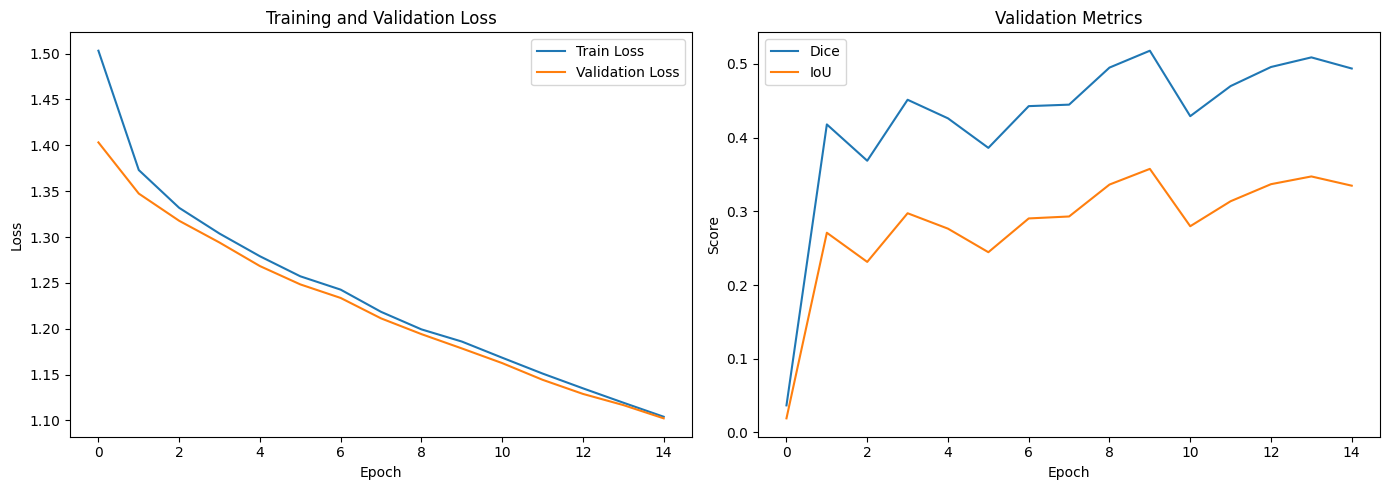

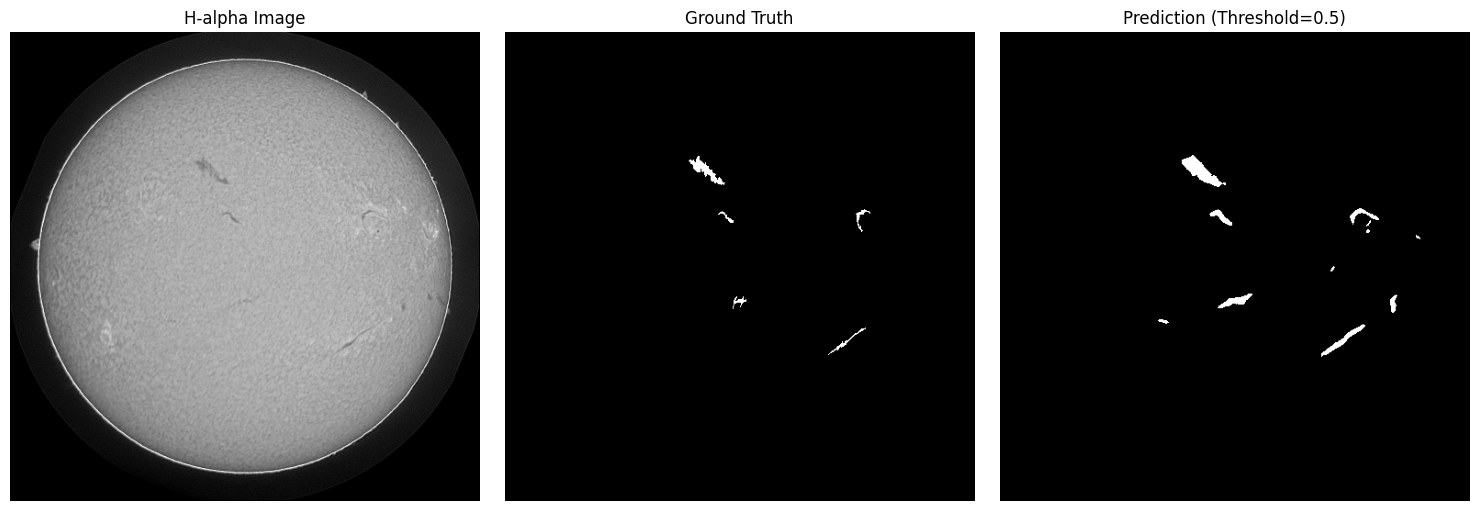

In [10]:
# ============================================
# 09. VALIDATION + PROBABILITY-MAP CACHING
# ============================================

model.eval()


val_predictions = []
val_targets = []
val_filenames_cached = []


print("============================================")
print("VALIDATION INFERENCE")
print("============================================")


with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(
            device,
            non_blocking=True
        )


        logits = model(
            images
        )


        probabilities = (
            torch.sigmoid(logits)
            .cpu()
            .numpy()
        )


        masks_np = (
            masks.numpy()
        )


        # ----------------------------------------
        # STORE EACH IMAGE
        # ----------------------------------------

        for i in range(
            len(images)
        ):

            val_predictions.append(
                probabilities[i, 0]
            )

            val_targets.append(
                masks_np[i, 0]
            )


# ============================================
# MATCH FILENAMES TO PREDICTIONS
# ============================================

val_filenames_cached = list(
    val_names
)


# ============================================
# BASIC CHECK
# ============================================

assert len(
    val_predictions
) == len(val_filenames_cached)

assert len(
    val_targets
) == len(val_filenames_cached)


print(
    f"Validation images cached: "
    f"{len(val_predictions)}"
)


print(
    "Prediction shape:",
    val_predictions[0].shape
)


# ============================================
# PIXEL-LEVEL VALIDATION
# ============================================

validation_dice = []

validation_iou = []


for probability, target in zip(
    val_predictions,
    val_targets
):

    validation_dice.append(
        calculate_dice(
            probability,
            target,
            threshold=DEFAULT_THRESHOLD
        )
    )

    validation_iou.append(
        calculate_iou(
            probability,
            target,
            threshold=DEFAULT_THRESHOLD
        )
    )


print("\n============================================")
print("VALIDATION RESULTS")
print("============================================")

print(
    f"Mean Dice : {np.mean(validation_dice):.4f}"
)

print(
    f"Mean IoU  : {np.mean(validation_iou):.4f}"
)


# ============================================
# TRAINING CURVES
# ============================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


axes[0].plot(
    train_losses,
    label="Train Loss"
)

axes[0].plot(
    val_losses,
    label="Validation Loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()


axes[1].plot(
    val_dice_scores,
    label="Dice"
)

axes[1].plot(
    val_iou_scores,
    label="IoU"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Metrics")
axes[1].legend()


plt.tight_layout()
plt.show()


# ============================================
# SAMPLE PREDICTION VISUALIZATION
# ============================================

sample_idx = 0

sample_filename = (
    val_filenames_cached[sample_idx]
)

sample_image = np.array(
    Image.open(
        TRAIN_IMAGES_DIR / sample_filename
    ).convert("L")
)

sample_probability = (
    val_predictions[sample_idx]
)

sample_target = (
    val_targets[sample_idx]
)

sample_prediction = (
    sample_probability >= DEFAULT_THRESHOLD
)


# Resize original image for visualization
sample_image_resized = cv2.resize(
    sample_image,
    (IMAGE_SIZE, IMAGE_SIZE),
    interpolation=cv2.INTER_AREA
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


axes[0].imshow(
    sample_image_resized,
    cmap="gray"
)

axes[0].set_title("H-alpha Image")
axes[0].axis("off")


axes[1].imshow(
    sample_target,
    cmap="gray"
)

axes[1].set_title("Ground Truth")
axes[1].axis("off")


axes[2].imshow(
    sample_prediction,
    cmap="gray"
)

axes[2].set_title(
    f"Prediction (Threshold={DEFAULT_THRESHOLD})"
)

axes[2].axis("off")


plt.tight_layout()
plt.show()

# Postprocessing Utilities

POSTPROCESSING CHECK
Sample image: 20160223173514Mh.jpeg
Number of predicted instances: 7
Largest instance areas: [615, 290, 236, 170, 161, 96, 34]


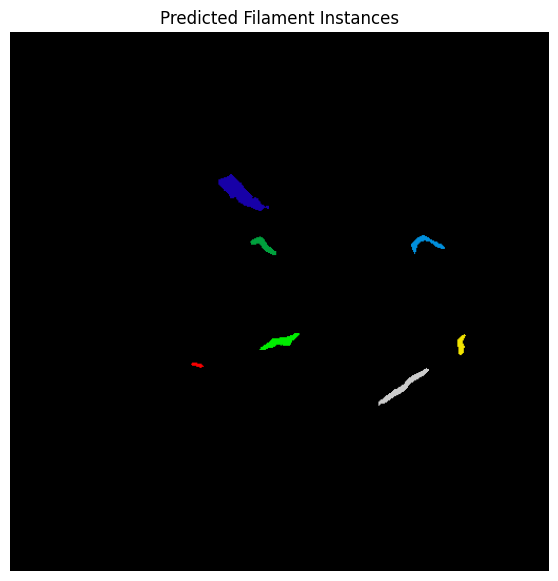

In [11]:
# ============================================
# 10. POSTPROCESSING UTILITIES
# ============================================

def remove_small_components(
    binary_mask,
    min_area=25,
    connectivity=8
):

    binary_mask = (
        binary_mask > 0
    ).astype(np.uint8)


    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=connectivity
        )
    )


    filtered_mask = np.zeros_like(
        binary_mask,
        dtype=np.uint8
    )


    for label_id in range(
        1,
        num_labels
    ):

        area = stats[
            label_id,
            cv2.CC_STAT_AREA
        ]


        if area >= min_area:

            filtered_mask[
                labels == label_id
            ] = 1


    return filtered_mask


def extract_connected_components(
    binary_mask,
    min_area=25,
    connectivity=8
):

    binary_mask = (
        binary_mask > 0
    ).astype(np.uint8)


    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=connectivity
        )
    )


    instances = []


    for label_id in range(
        1,
        num_labels
    ):

        area = stats[
            label_id,
            cv2.CC_STAT_AREA
        ]


        if area < min_area:
            continue


        instance_mask = (
            labels == label_id
        ).astype(np.uint8)


        instances.append(
            instance_mask
        )


    return instances


# ============================================
# PROBABILITY → INSTANCE MASKS
# ============================================

def probability_to_instances(
    probability,
    threshold=0.5,
    min_area=25
):

    binary_mask = (
        probability >= threshold
    ).astype(np.uint8)


    instances = extract_connected_components(
        binary_mask,
        min_area=min_area,
        connectivity=8
    )


    return instances


# ============================================
# INSTANCE AREA
# ============================================

def get_instance_areas(
    instances
):

    return [
        int(instance.sum())
        for instance in instances
    ]


# ============================================
# QUICK VALIDATION
# ============================================

sample_probability = (
    val_predictions[0]
)

sample_instances = (
    probability_to_instances(
        sample_probability,
        threshold=DEFAULT_THRESHOLD,
        min_area=DEFAULT_MIN_AREA
    )
)


print("============================================")
print("POSTPROCESSING CHECK")
print("============================================")

print(
    "Sample image:",
    val_filenames_cached[0]
)

print(
    "Number of predicted instances:",
    len(sample_instances)
)

print(
    "Largest instance areas:",
    sorted(
        get_instance_areas(
            sample_instances
        ),
        reverse=True
    )[:10]
)


# ============================================
# VISUALIZE INSTANCE LABEL MAP
# ============================================

instance_visualization = np.zeros(
    (
        IMAGE_SIZE,
        IMAGE_SIZE
    ),
    dtype=np.int32
)


for instance_id, instance_mask in enumerate(
    sample_instances,
    start=1
):

    instance_visualization[
        instance_mask.astype(bool)
    ] = instance_id


plt.figure(figsize=(7, 7))

plt.imshow(
    instance_visualization,
    cmap="nipy_spectral"
)

plt.title(
    "Predicted Filament Instances"
)

plt.axis("off")

plt.show()

# Threshold & Minimum-Area Optimization

In [12]:
# ============================================
# 11. THRESHOLD + MINIMUM-AREA OPTIMIZATION
# ============================================

from scipy.optimize import linear_sum_assignment


# ============================================
# PANOPTIC MATCHING CONFIGURATION
# ============================================

PQ_IOU_THRESHOLD = 0.50


# ============================================
# CREATE GT INSTANCE MASKS
# ============================================

def create_gt_instances(
    filename,
    target_size=(512, 512)
):

    anns = filename_to_annotations.get(
        filename,
        []
    )

    instances = []


    # ----------------------------------------
    # ORIGINAL IMAGE SIZE
    # ----------------------------------------

    image_path = (
        TRAIN_IMAGES_DIR / filename
    )

    image = Image.open(
        image_path
    )

    original_width, original_height = (
        image.size
    )


    # ----------------------------------------
    # CREATE ONE MASK PER ANNOTATION
    # ----------------------------------------

    for ann in anns:

        mask = Image.new(
            "L",
            (
                original_width,
                original_height
            ),
            0
        )

        draw = ImageDraw.Draw(mask)


        segmentation = ann.get(
            "segmentation",
            []
        )


        for polygon in segmentation:

            if len(polygon) < 6:
                continue


            points = [
                (
                    polygon[i],
                    polygon[i + 1]
                )
                for i in range(
                    0,
                    len(polygon),
                    2
                )
            ]


            draw.polygon(
                points,
                fill=1
            )


        # ------------------------------------
        # RESIZE TO MODEL OUTPUT SIZE
        # ------------------------------------

        mask = mask.resize(
            target_size,
            Image.Resampling.NEAREST
        )


        mask = np.asarray(
            mask,
            dtype=np.uint8
        )


        if mask.sum() > 0:

            instances.append(mask)


    return instances


# ============================================
# MASK IoU
# ============================================

def mask_iou(
    mask1,
    mask2
):

    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)


    intersection = np.logical_and(
        mask1,
        mask2
    ).sum()


    union = np.logical_or(
        mask1,
        mask2
    ).sum()


    if union == 0:
        return 0.0


    return (
        intersection / union
    )


# ============================================
# INSTANCE IoU MATRIX
# ============================================

def calculate_iou_matrix(
    gt_instances,
    pred_instances
):

    num_gt = len(gt_instances)
    num_pred = len(pred_instances)


    iou_matrix = np.zeros(
        (
            num_gt,
            num_pred
        ),
        dtype=np.float32
    )


    for gt_idx, gt_mask in enumerate(
        gt_instances
    ):

        for pred_idx, pred_mask in enumerate(
            pred_instances
        ):

            iou_matrix[
                gt_idx,
                pred_idx
            ] = mask_iou(
                gt_mask,
                pred_mask
            )


    return iou_matrix


# ============================================
# ONE-TO-ONE INSTANCE MATCHING
# ============================================

def match_instances(
    gt_instances,
    pred_instances,
    iou_threshold=0.50
):

    num_gt = len(gt_instances)
    num_pred = len(pred_instances)


    # ----------------------------------------
    # EMPTY CASE
    # ----------------------------------------

    if num_gt == 0 or num_pred == 0:

        return {
            "matches": [],
            "tp": 0,
            "fp": num_pred,
            "fn": num_gt,
            "iou_matrix": np.zeros(
                (num_gt, num_pred),
                dtype=np.float32
            )
        }


    # ----------------------------------------
    # IoU MATRIX
    # ----------------------------------------

    iou_matrix = calculate_iou_matrix(
        gt_instances,
        pred_instances
    )


    # ----------------------------------------
    # HUNGARIAN ASSIGNMENT
    # ----------------------------------------

    row_indices, col_indices = (
        linear_sum_assignment(
            -iou_matrix
        )
    )


    matches = []


    for gt_idx, pred_idx in zip(
        row_indices,
        col_indices
    ):

        iou = iou_matrix[
            gt_idx,
            pred_idx
        ]


        if iou >= iou_threshold:

            matches.append(
                (
                    gt_idx,
                    pred_idx,
                    float(iou)
                )
            )


    tp = len(matches)

    fp = num_pred - tp
    fn = num_gt - tp


    return {
        "matches": matches,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "iou_matrix": iou_matrix
    }


# ============================================
# PANOPTIC QUALITY
# ============================================

def calculate_pq(
    gt_instances,
    pred_instances,
    iou_threshold=0.50
):

    matching = match_instances(
        gt_instances,
        pred_instances,
        iou_threshold=iou_threshold
    )


    matches = matching["matches"]

    tp = matching["tp"]
    fp = matching["fp"]
    fn = matching["fn"]


    sum_iou = sum(
        match[2]
        for match in matches
    )


    denominator = (
        tp
        + 0.5 * fp
        + 0.5 * fn
    )


    if denominator == 0:

        # No GT and no prediction.
        # Treat as perfect for this image.
        pq = 1.0

    else:

        pq = (
            sum_iou / denominator
        )


    return {
        "pq": float(pq),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "sum_iou": float(sum_iou),
        "matches": matches,
        "iou_matrix": matching["iou_matrix"]
    }


# ============================================
# TEST GT INSTANCE CREATION
# ============================================

sample_filename = (
    val_filenames_cached[0]
)

sample_gt_instances = (
    create_gt_instances(
        sample_filename,
        target_size=(
            IMAGE_SIZE,
            IMAGE_SIZE
        )
    )
)


print("============================================")
print("INSTANCE EVALUATION SETUP")
print("============================================")

print(
    "Sample image:",
    sample_filename
)

print(
    "GT filament instances:",
    len(sample_gt_instances)
)


# ============================================
# THRESHOLD + AREA GRID
# ============================================

THRESHOLDS = [
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80
]

MIN_AREAS = [
    5,
    10,
    25,
    50,
    75,
    100
]


optimization_results = []


print("\n============================================")
print("POSTPROCESSING OPTIMIZATION")
print("============================================")


for threshold in THRESHOLDS:

    print(
        f"\nTesting threshold = {threshold:.2f}"
    )


    # ----------------------------------------
    # PRECOMPUTE BINARY MASKS FOR THRESHOLD
    # ----------------------------------------

    binary_predictions = []

    for probability in val_predictions:

        binary_predictions.append(
            (
                probability >= threshold
            ).astype(np.uint8)
        )


    for min_area in MIN_AREAS:

        pq_scores = []
        total_tp = 0
        total_fp = 0
        total_fn = 0


        for idx in range(
            len(val_predictions)
        ):

            # --------------------------------
            # PREDICTED INSTANCES
            # --------------------------------

            pred_instances = (
                extract_connected_components(
                    binary_predictions[idx],
                    min_area=min_area,
                    connectivity=8
                )
            )


            # --------------------------------
            # GT INSTANCES
            # --------------------------------

            gt_instances = (
                create_gt_instances(
                    val_filenames_cached[idx],
                    target_size=(
                        IMAGE_SIZE,
                        IMAGE_SIZE
                    )
                )
            )


            # --------------------------------
            # PQ
            # --------------------------------

            result = calculate_pq(
                gt_instances,
                pred_instances,
                iou_threshold=PQ_IOU_THRESHOLD
            )


            pq_scores.append(
                result["pq"]
            )

            total_tp += result["tp"]
            total_fp += result["fp"]
            total_fn += result["fn"]


        mean_pq = np.mean(
            pq_scores
        )


        optimization_results.append({

            "threshold": threshold,

            "min_area": min_area,

            "pq": mean_pq,

            "tp": total_tp,

            "fp": total_fp,

            "fn": total_fn

        })


# ============================================
# FIND BEST CONFIGURATION
# ============================================

optimization_df = pd.DataFrame(
    optimization_results
)


best_result = optimization_df.loc[
    optimization_df["pq"].idxmax()
]


BEST_THRESHOLD = float(
    best_result["threshold"]
)

BEST_MIN_AREA = int(
    best_result["min_area"]
)


print("\n============================================")
print("BEST CONFIGURATION")
print("============================================")

print(
    f"Best threshold : {BEST_THRESHOLD:.2f}"
)

print(
    f"Best min area  : {BEST_MIN_AREA}"
)

print(
    f"Best PQ        : {best_result['pq']:.4f}"
)


# ============================================
# SHOW TOP CONFIGURATIONS
# ============================================

print("\nTop configurations:")

display(
    optimization_df
    .sort_values(
        "pq",
        ascending=False
    )
    .head(10)
)

INSTANCE EVALUATION SETUP
Sample image: 20160223173514Mh.jpeg
GT filament instances: 5

POSTPROCESSING OPTIMIZATION

Testing threshold = 0.40

Testing threshold = 0.45

Testing threshold = 0.50

Testing threshold = 0.55

Testing threshold = 0.60

Testing threshold = 0.65

Testing threshold = 0.70

Testing threshold = 0.75

Testing threshold = 0.80

BEST CONFIGURATION
Best threshold : 0.80
Best min area  : 50
Best PQ        : 0.2532

Top configurations:


,threshold,min_area,pq,tp,fp,fn
51,0.80,50,0.253163,436,553,678
50,0.80,25,0.246075,491,823,623
52,0.80,75,0.244175,384,419,730
49,0.80,10,0.223632,504,1116,610
53,0.80,100,0.222743,320,329,794
45,0.75,50,0.222311,409,658,705
44,0.75,25,0.218237,466,928,648
46,0.75,75,0.215055,361,515,753
48,0.80,5,0.209758,504,1305,610
47,0.75,100,0.205484,314,397,800


# Instance Extraction & One-to-One Matching

In [13]:
# ============================================
# 12. INSTANCE EXTRACTION + ONE-TO-ONE MATCHING
# ============================================

instance_results = []


print("============================================")
print("INSTANCE-LEVEL VALIDATION")
print("============================================")


for idx in range(
    len(val_predictions)
):

    filename = (
        val_filenames_cached[idx]
    )


    probability = (
        val_predictions[idx]
    )


    # ========================================
    # PREDICTED INSTANCES
    # ========================================

    pred_instances = (
        probability_to_instances(
            probability,
            threshold=BEST_THRESHOLD,
            min_area=BEST_MIN_AREA
        )
    )


    # ========================================
    # GROUND-TRUTH INSTANCES
    # ========================================

    gt_instances = (
        create_gt_instances(
            filename,
            target_size=(
                IMAGE_SIZE,
                IMAGE_SIZE
            )
        )
    )


    # ========================================
    # MATCH INSTANCES
    # ========================================

    result = calculate_pq(
        gt_instances,
        pred_instances,
        iou_threshold=PQ_IOU_THRESHOLD
    )


    # ========================================
    # STORE RESULT
    # ========================================

    instance_results.append({

        "filename": filename,

        "num_gt": len(gt_instances),

        "num_pred": len(pred_instances),

        "tp": result["tp"],

        "fp": result["fp"],

        "fn": result["fn"],

        "pq": result["pq"],

        "sum_iou": result["sum_iou"],

        "matches": result["matches"],

        "iou_matrix": result["iou_matrix"]

    })


# ============================================
# SUMMARY
# ============================================

instance_summary = pd.DataFrame([
    {
        "filename": result["filename"],
        "num_gt": result["num_gt"],
        "num_pred": result["num_pred"],
        "tp": result["tp"],
        "fp": result["fp"],
        "fn": result["fn"],
        "pq": result["pq"]
    }
    for result in instance_results
])


print("\n============================================")
print("INSTANCE SUMMARY")
print("============================================")

print(
    f"Mean PQ : "
    f"{instance_summary['pq'].mean():.4f}"
)

print(
    f"Total GT instances : "
    f"{instance_summary['num_gt'].sum()}"
)

print(
    f"Total predictions  : "
    f"{instance_summary['num_pred'].sum()}"
)

print(
    f"Total TP : "
    f"{instance_summary['tp'].sum()}"
)

print(
    f"Total FP : "
    f"{instance_summary['fp'].sum()}"
)

print(
    f"Total FN : "
    f"{instance_summary['fn'].sum()}"
)


# ============================================
# WORST PQ IMAGES
# ============================================

print("\nWorst PQ images:")

display(
    instance_summary
    .sort_values(
        "pq",
        ascending=True
    )
    .head(10)
)

INSTANCE-LEVEL VALIDATION

INSTANCE SUMMARY
Mean PQ : 0.2532
Total GT instances : 1114
Total predictions  : 989
Total TP : 436
Total FP : 553
Total FN : 678

Worst PQ images:


,filename,num_gt,num_pred,tp,fp,fn,pq
31,20170107133714Th.jpeg,1,2,0,2,1,0.000000
58,20190926165810Mh.jpeg,1,1,0,1,1,0.000000
41,20170102024454Uh.jpeg,2,2,0,2,2,0.000000
38,20181102104630Ch.jpeg,1,2,0,2,1,0.000000
104,20190602025430Lh.jpeg,3,0,0,0,3,0.000000
118,20170801164710Mh.jpeg,6,3,0,3,6,0.000000
66,20211016145050Bh.jpeg,2,0,0,0,2,0.000000
128,20110205082634Lh.jpeg,2,4,0,4,2,0.000000
122,20110724164614Mh.jpeg,9,6,1,5,8,0.074252
18,20130319144654Bh.jpeg,6,9,1,8,5,0.075039


# PQ & Dice/IoU & Fragmentation/Merging

FINAL VALIDATION METRICS
Panoptic Quality : 0.2525
TP : 436
FP : 553
FN : 678

Matched Dice mean : 0.7544
Matched Dice median : 0.7462
Matched IoU mean : 0.6089
Matched IoU median : 0.5952

FRAGMENTATION / MERGING
One-to-many GT relations : 34
Many-to-one GT relations : 19


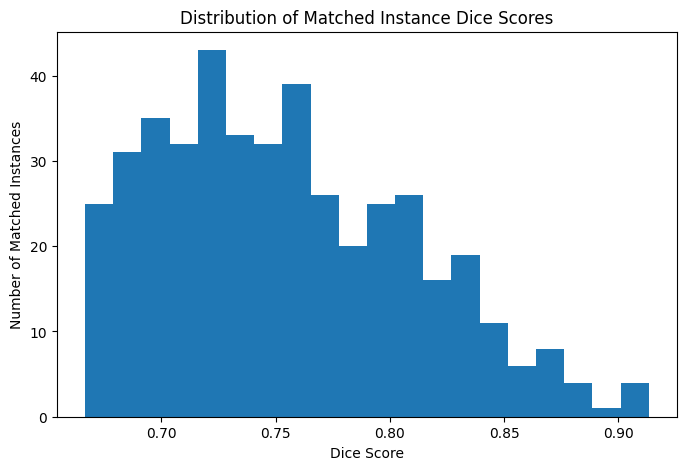

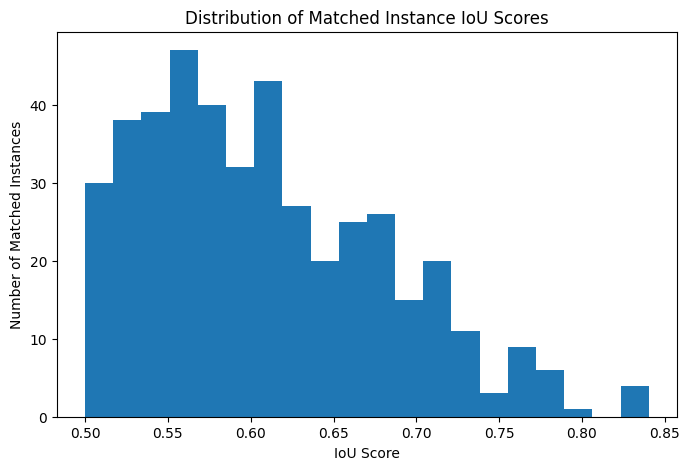

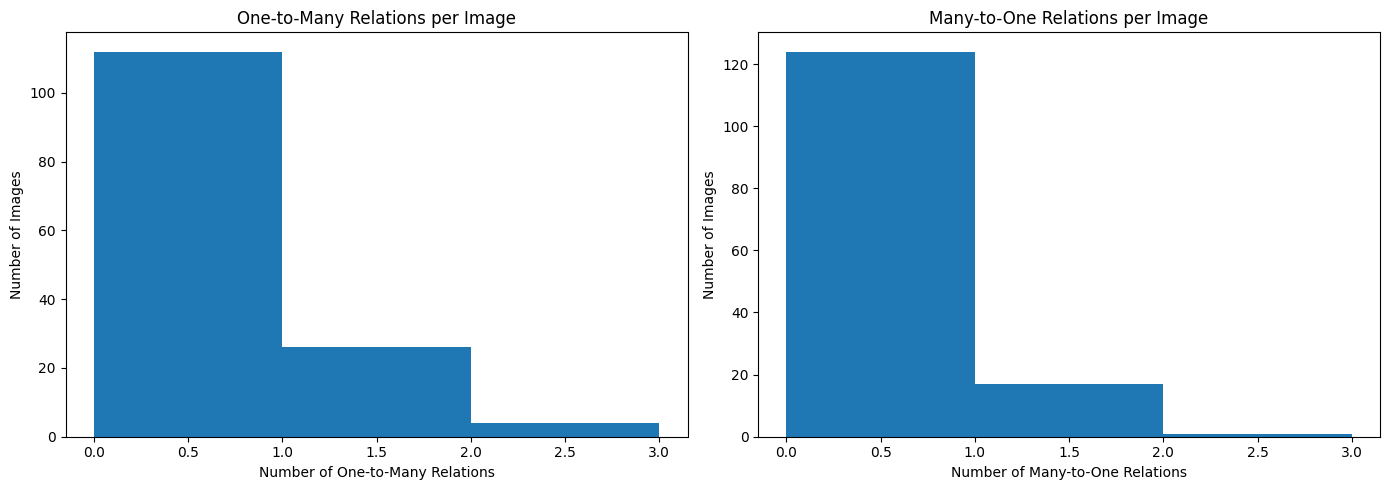

In [14]:
# ============================================
# 13. PQ + DICE/IoU + FRAGMENTATION/MERGING
# ============================================


# ============================================
# STORAGE
# ============================================

matched_dice_scores = []
matched_iou_scores = []

one_to_many_counts = []
many_to_one_counts = []

all_tp = 0
all_fp = 0
all_fn = 0
all_sum_iou = 0.0


# ============================================
# RELATIONSHIP IoU THRESHOLD
# ============================================

RELATION_IOU_THRESHOLD = 0.10


# ============================================
# HELPER: DICE
# ============================================

def mask_dice(
    mask1,
    mask2,
    smooth=1e-6
):

    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)


    intersection = np.logical_and(
        mask1,
        mask2
    ).sum()


    dice = (
        2.0 * intersection + smooth
    ) / (
        mask1.sum()
        + mask2.sum()
        + smooth
    )


    return float(dice)


# ============================================
# EVALUATE ALL VALIDATION IMAGES
# ============================================

for result_idx, result in enumerate(
    instance_results
):

    filename = result["filename"]

    gt_instances = (
        create_gt_instances(
            filename,
            target_size=(
                IMAGE_SIZE,
                IMAGE_SIZE
            )
        )
    )


    probability = (
        val_predictions[result_idx]
    )


    pred_instances = (
        probability_to_instances(
            probability,
            threshold=BEST_THRESHOLD,
            min_area=BEST_MIN_AREA
        )
    )


    iou_matrix = result[
        "iou_matrix"
    ]


    # ========================================
    # GLOBAL PQ COUNTS
    # ========================================

    all_tp += result["tp"]
    all_fp += result["fp"]
    all_fn += result["fn"]
    all_sum_iou += result["sum_iou"]


    # ========================================
    # MATCHED DICE + IoU
    # ========================================

    for (
        gt_idx,
        pred_idx,
        iou
    ) in result["matches"]:

        gt_mask = gt_instances[
            gt_idx
        ]

        pred_mask = pred_instances[
            pred_idx
        ]


        matched_iou_scores.append(
            iou
        )

        matched_dice_scores.append(
            mask_dice(
                gt_mask,
                pred_mask
            )
        )


    # ========================================
    # ONE-TO-MANY
    # ========================================
    #
    # One GT overlaps multiple predictions.
    # ========================================

    image_one_to_many = 0


    for gt_idx in range(
        len(gt_instances)
    ):

        if len(pred_instances) == 0:
            continue


        overlapping_predictions = np.sum(
            iou_matrix[
                gt_idx
            ] >= RELATION_IOU_THRESHOLD
        )


        if overlapping_predictions > 1:

            image_one_to_many += 1


    one_to_many_counts.append(
        image_one_to_many
    )


    # ========================================
    # MANY-TO-ONE
    # ========================================
    #
    # One prediction overlaps multiple GTs.
    # ========================================

    image_many_to_one = 0


    for pred_idx in range(
        len(pred_instances)
    ):

        if len(gt_instances) == 0:
            continue


        overlapping_gt = np.sum(
            iou_matrix[
                :,
                pred_idx
            ] >= RELATION_IOU_THRESHOLD
        )


        if overlapping_gt > 1:

            image_many_to_one += 1


    many_to_one_counts.append(
        image_many_to_one
    )


# ============================================
# GLOBAL PQ
# ============================================

global_denominator = (
    all_tp
    + 0.5 * all_fp
    + 0.5 * all_fn
)


if global_denominator > 0:

    GLOBAL_PQ = (
        all_sum_iou
        / global_denominator
    )

else:

    GLOBAL_PQ = 1.0


# ============================================
# SUMMARY
# ============================================

print("============================================")
print("FINAL VALIDATION METRICS")
print("============================================")

print(
    f"Panoptic Quality : {GLOBAL_PQ:.4f}"
)

print(
    f"TP : {all_tp}"
)

print(
    f"FP : {all_fp}"
)

print(
    f"FN : {all_fn}"
)


# ============================================
# DICE / IoU DISTRIBUTIONS
# ============================================

if matched_dice_scores:

    print(
        f"\nMatched Dice mean : "
        f"{np.mean(matched_dice_scores):.4f}"
    )

    print(
        f"Matched Dice median : "
        f"{np.median(matched_dice_scores):.4f}"
    )


if matched_iou_scores:

    print(
        f"Matched IoU mean : "
        f"{np.mean(matched_iou_scores):.4f}"
    )

    print(
        f"Matched IoU median : "
        f"{np.median(matched_iou_scores):.4f}"
    )


# ============================================
# FRAGMENTATION / MERGING
# ============================================

total_one_to_many = sum(
    one_to_many_counts
)

total_many_to_one = sum(
    many_to_one_counts
)


print("\n============================================")
print("FRAGMENTATION / MERGING")
print("============================================")

print(
    f"One-to-many GT relations : "
    f"{total_one_to_many}"
)

print(
    f"Many-to-one GT relations : "
    f"{total_many_to_one}"
)


# ============================================
# DICE DISTRIBUTION
# ============================================

if matched_dice_scores:

    plt.figure(figsize=(8, 5))

    plt.hist(
        matched_dice_scores,
        bins=20
    )

    plt.xlabel("Dice Score")
    plt.ylabel("Number of Matched Instances")
    plt.title("Distribution of Matched Instance Dice Scores")

    plt.show()


# ============================================
# IoU DISTRIBUTION
# ============================================

if matched_iou_scores:

    plt.figure(figsize=(8, 5))

    plt.hist(
        matched_iou_scores,
        bins=20
    )

    plt.xlabel("IoU Score")
    plt.ylabel("Number of Matched Instances")
    plt.title("Distribution of Matched Instance IoU Scores")

    plt.show()


# ============================================
# ONE-TO-MANY / MANY-TO-ONE DISTRIBUTION
# ============================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


axes[0].hist(
    one_to_many_counts,
    bins=range(
        0,
        max(one_to_many_counts + [1]) + 2
    )
)

axes[0].set_title(
    "One-to-Many Relations per Image"
)

axes[0].set_xlabel(
    "Number of One-to-Many Relations"
)

axes[0].set_ylabel(
    "Number of Images"
)


axes[1].hist(
    many_to_one_counts,
    bins=range(
        0,
        max(many_to_one_counts + [1]) + 2
    )
)

axes[1].set_title(
    "Many-to-One Relations per Image"
)

axes[1].set_xlabel(
    "Number of Many-to-One Relations"
)

axes[1].set_ylabel(
    "Number of Images"
)


plt.tight_layout()
plt.show()

# Error Analysis & Visualization

ERROR ANALYSIS
Worst PQ: 20170107133714Th.jpeg
Best PQ: 20171109023950Uh.jpeg
Most FP: 20150706083014Th.jpeg
Most FN: 20150518145654Bh.jpeg


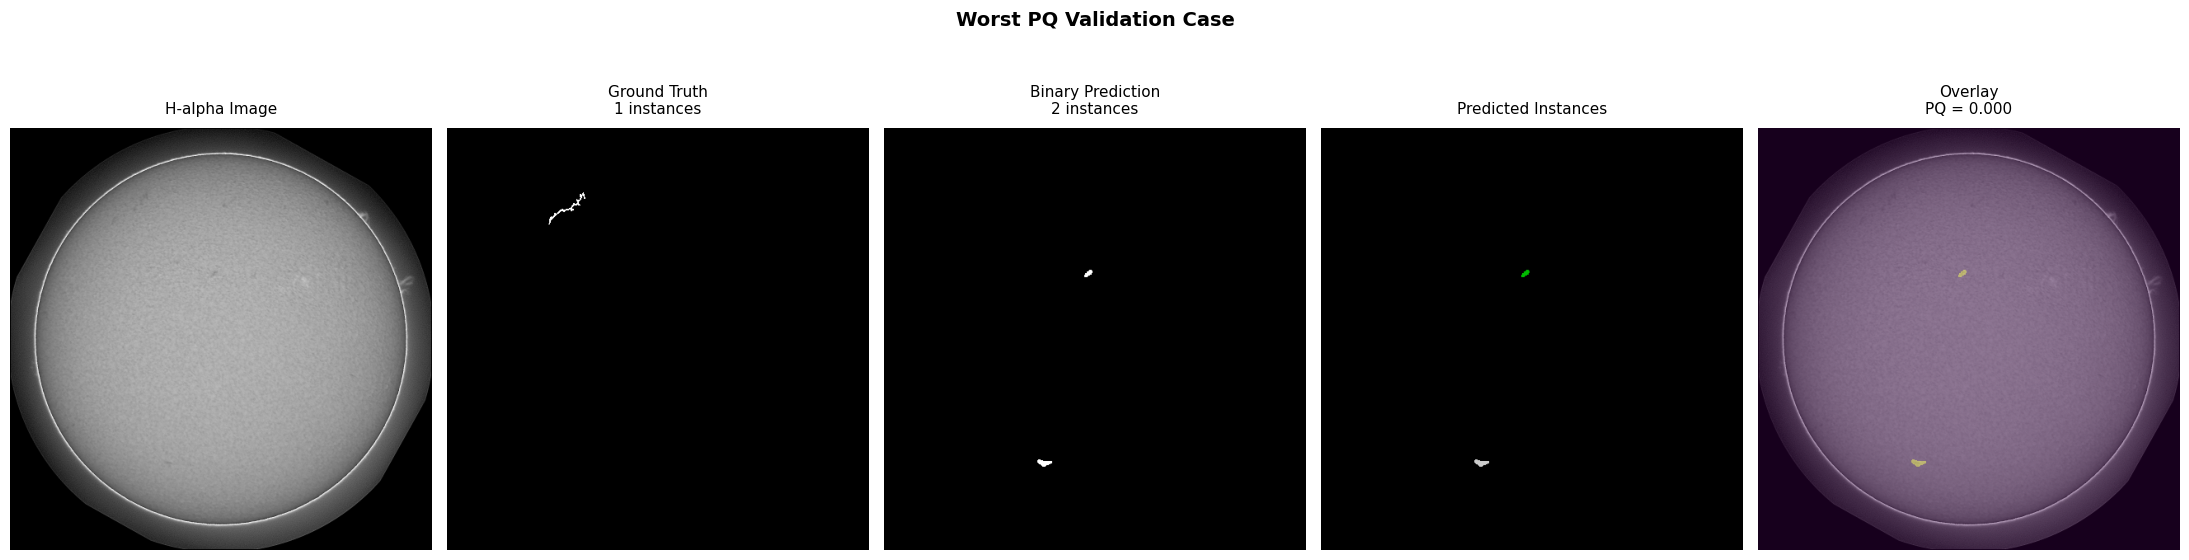

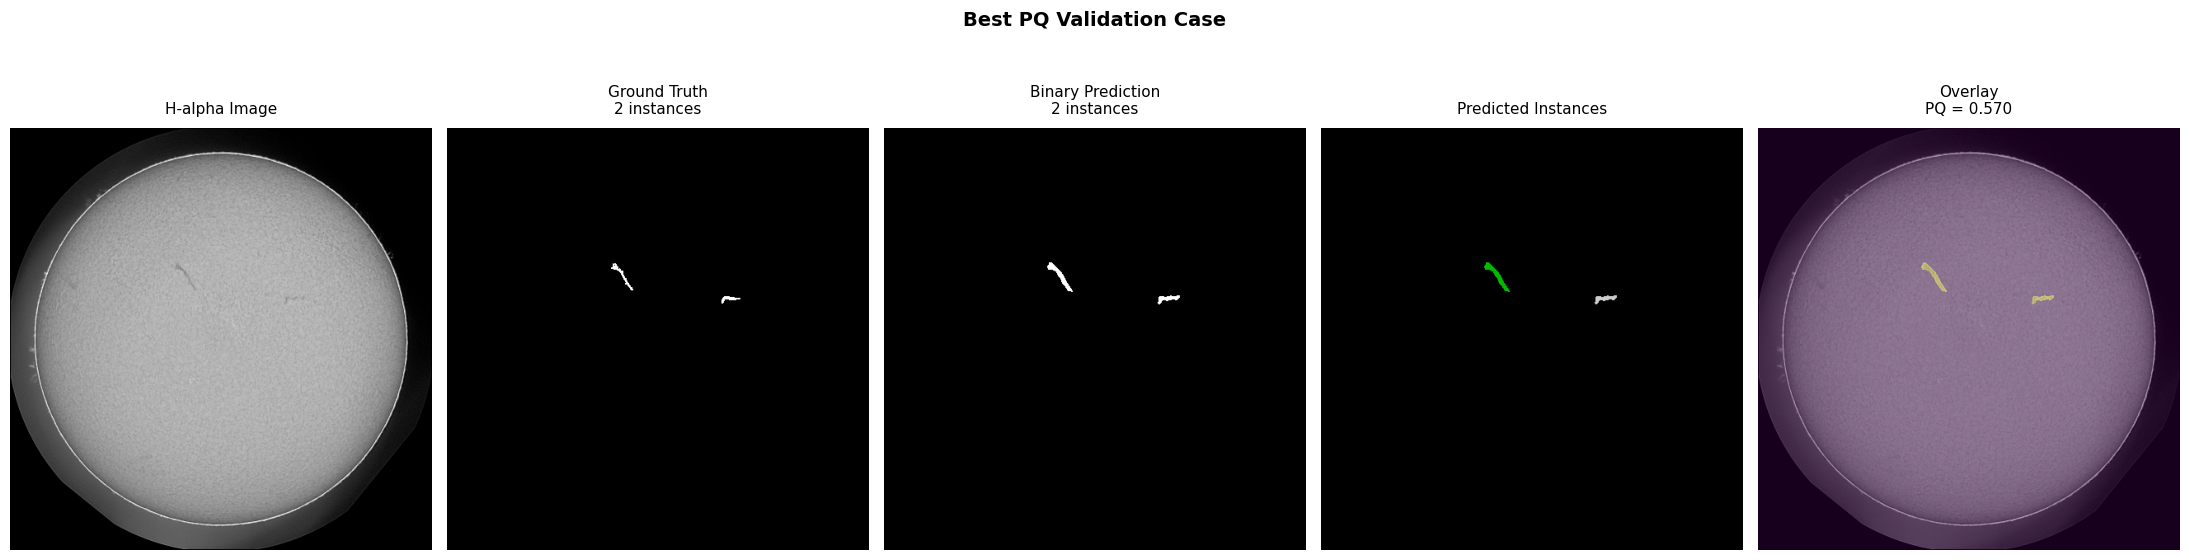

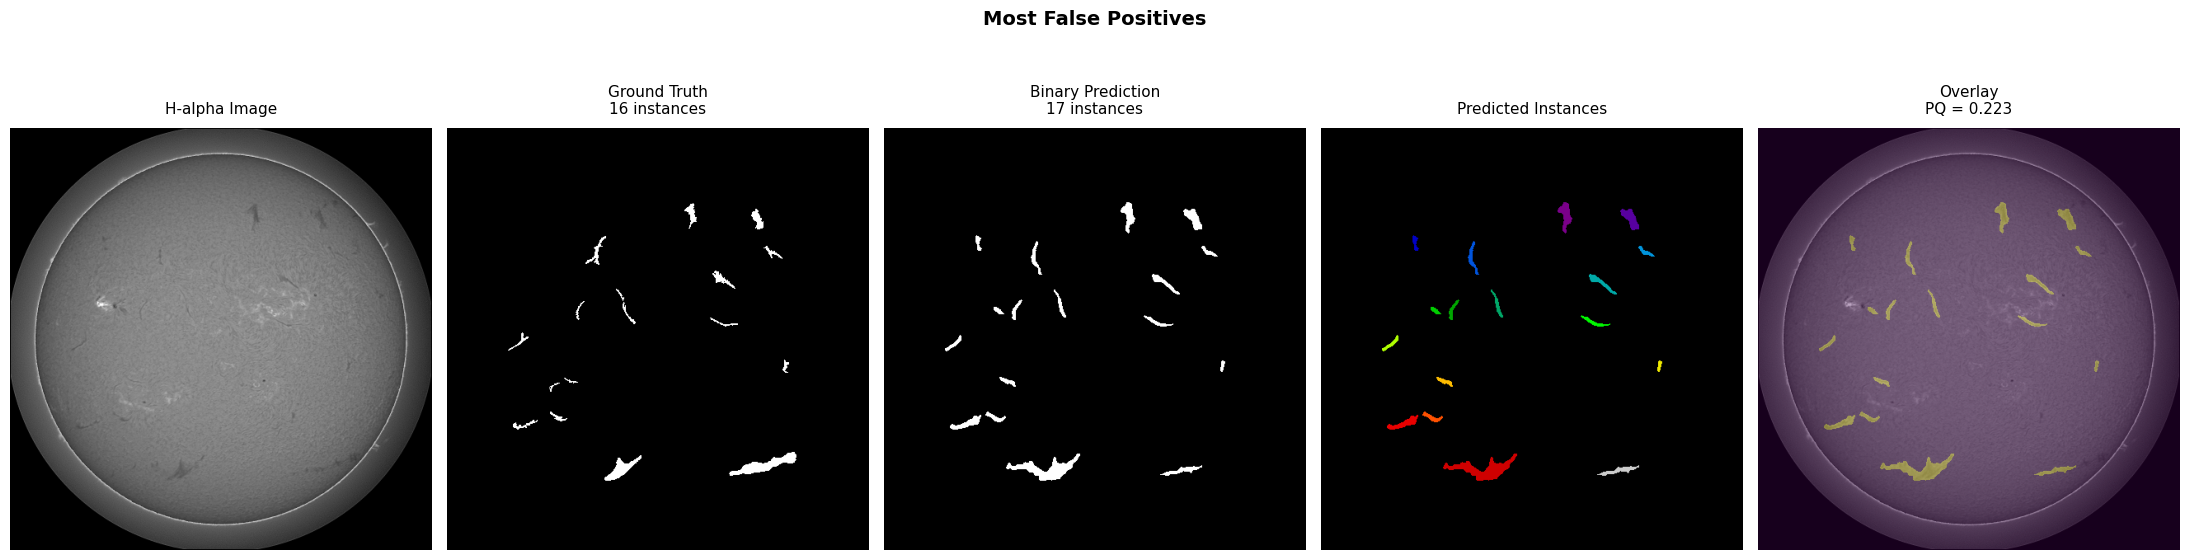

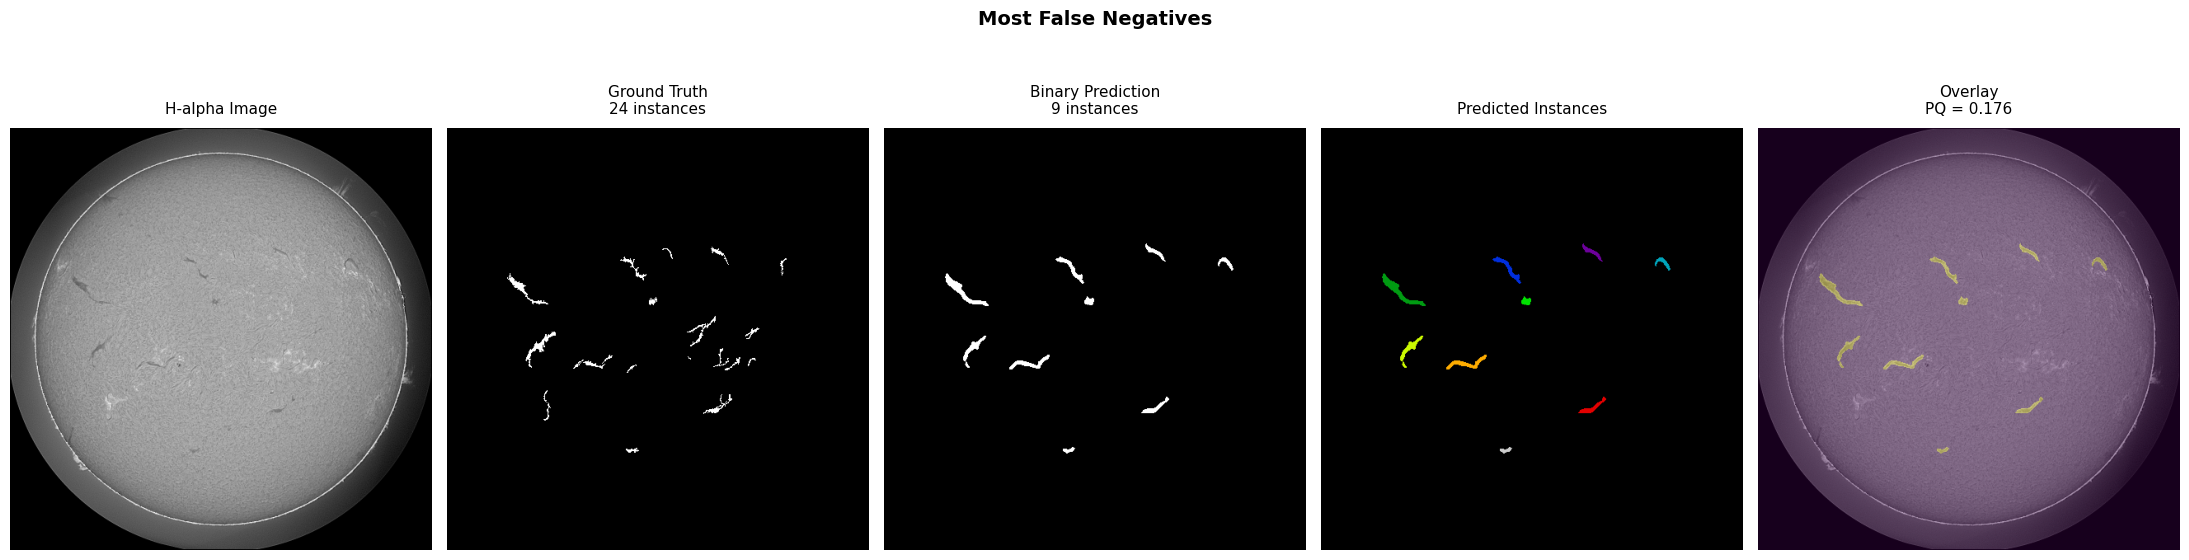

In [16]:
# ============================================
# 14. ERROR ANALYSIS + VISUALIZATION
# ============================================


# ============================================
# FIND IMPORTANT CASES
# ============================================

worst_pq_idx = (
    instance_summary["pq"]
    .idxmin()
)

best_pq_idx = (
    instance_summary["pq"]
    .idxmax()
)

most_fp_idx = (
    instance_summary["fp"]
    .idxmax()
)

most_fn_idx = (
    instance_summary["fn"]
    .idxmax()
)


print("============================================")
print("ERROR ANALYSIS")
print("============================================")

print(
    "Worst PQ:",
    instance_summary.loc[
        worst_pq_idx,
        "filename"
    ]
)

print(
    "Best PQ:",
    instance_summary.loc[
        best_pq_idx,
        "filename"
    ]
)

print(
    "Most FP:",
    instance_summary.loc[
        most_fp_idx,
        "filename"
    ]
)

print(
    "Most FN:",
    instance_summary.loc[
        most_fn_idx,
        "filename"
    ]
)


# ============================================
# VISUALIZATION FUNCTION
# ============================================

def visualize_validation_case(
    idx,
    title=None
):

    filename = (
        val_filenames_cached[idx]
    )


    probability = (
        val_predictions[idx]
    )


    target = (
        val_targets[idx]
    )


    # ----------------------------------------
    # ORIGINAL IMAGE
    # ----------------------------------------

    image = np.array(
        Image.open(
            TRAIN_IMAGES_DIR / filename
        ).convert("L")
    )


    image = cv2.resize(
        image,
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=cv2.INTER_AREA
    )


    # ----------------------------------------
    # PREDICTED BINARY MASK
    # ----------------------------------------

    prediction = (
        probability >= BEST_THRESHOLD
    ).astype(np.uint8)


    prediction_filtered = (
        remove_small_components(
            prediction,
            min_area=BEST_MIN_AREA
        )
    )


    # ----------------------------------------
    # INSTANCE LABEL MAP
    # ----------------------------------------

    predicted_instances = (
        probability_to_instances(
            probability,
            threshold=BEST_THRESHOLD,
            min_area=BEST_MIN_AREA
        )
    )


    instance_map = np.zeros(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        dtype=np.int32
    )


    for instance_id, instance_mask in enumerate(
        predicted_instances,
        start=1
    ):

        instance_map[
            instance_mask.astype(bool)
        ] = instance_id


    # ----------------------------------------
    # GET METRICS
    # ----------------------------------------

    result = instance_results[idx]


    # ----------------------------------------
    # PLOT
    # ----------------------------------------

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(22, 6)
    )


    axes[0].imshow(
        image,
        cmap="gray"
    )

    axes[0].set_title(
        "H-alpha Image",
        fontsize=11,
        pad=10
    )

    axes[0].axis("off")


    axes[1].imshow(
        target,
        cmap="gray"
    )

    axes[1].set_title(
        f"Ground Truth\n"
        f"{result['num_gt']} instances",
        fontsize=11,
        pad=10
    )

    axes[1].axis("off")


    axes[2].imshow(
        prediction_filtered,
        cmap="gray"
    )

    axes[2].set_title(
        f"Binary Prediction\n"
        f"{result['num_pred']} instances",
        fontsize=11,
        pad=10
    )

    axes[2].axis("off")


    axes[3].imshow(
        instance_map,
        cmap="nipy_spectral"
    )

    axes[3].set_title(
        "Predicted Instances",
        fontsize=11,
        pad=10
    )

    axes[3].axis("off")


    axes[4].imshow(
        image,
        cmap="gray"
    )

    axes[4].imshow(
        prediction_filtered,
        alpha=0.35
    )

    axes[4].set_title(
        f"Overlay\n"
        f"PQ = {result['pq']:.3f}",
        fontsize=11,
        pad=10
    )

    axes[4].axis("off")


    if title is not None:

        fig.suptitle(
            title,
            fontsize=14,
            fontweight="bold",
            y=0.98
        )


    # ----------------------------------------
    # LAYOUT
    # ----------------------------------------

    plt.tight_layout(
        rect=[0, 0, 1, 0.92]
    )

    plt.show()


# ============================================
# WORST PQ CASE
# ============================================

visualize_validation_case(
    worst_pq_idx,
    title="Worst PQ Validation Case"
)


# ============================================
# BEST PQ CASE
# ============================================

visualize_validation_case(
    best_pq_idx,
    title="Best PQ Validation Case"
)


# ============================================
# MOST FALSE POSITIVES
# ============================================

visualize_validation_case(
    most_fp_idx,
    title="Most False Positives"
)


# ============================================
# MOST FALSE NEGATIVES
# ============================================

visualize_validation_case(
    most_fn_idx,
    title="Most False Negatives"
)

# Final Validation

FINAL VALIDATION
Instance method : Connected Components
Threshold       : 0.800
Minimum area    : 50
PQ              : 0.2525
TP              : 436
FP              : 553
FN              : 678
Mean Dice       : 0.7544
Mean IoU        : 0.6089


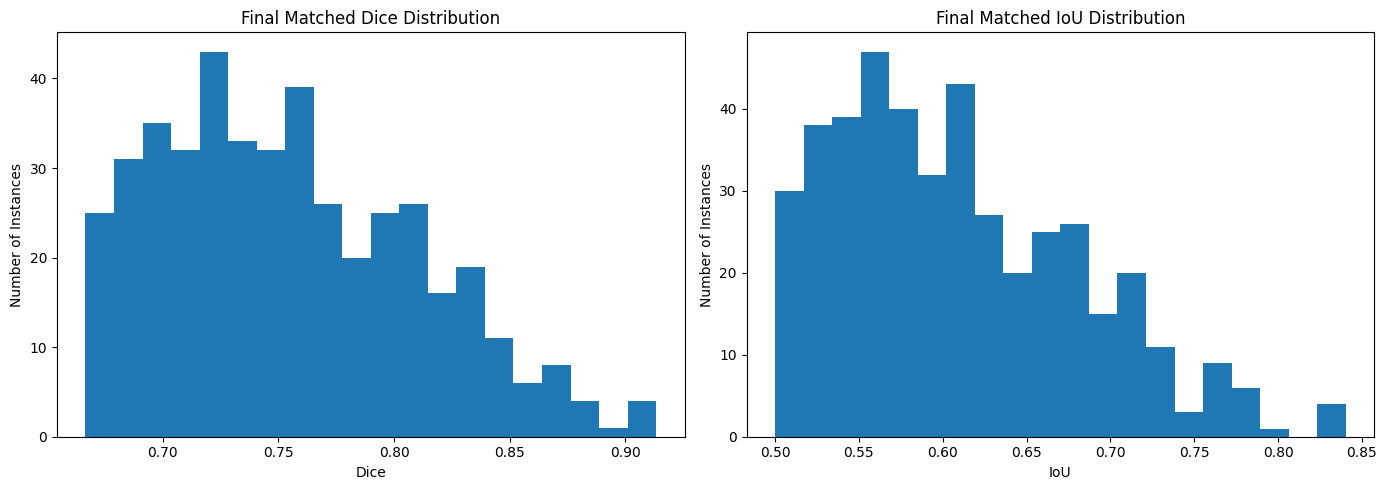


Worst validation cases:


,filename,num_gt,num_pred,tp,fp,fn,pq,sum_iou
31,20170107133714Th.jpeg,1,2,0,2,1,0.000000,0.000000
58,20190926165810Mh.jpeg,1,1,0,1,1,0.000000,0.000000
41,20170102024454Uh.jpeg,2,2,0,2,2,0.000000,0.000000
38,20181102104630Ch.jpeg,1,2,0,2,1,0.000000,0.000000
104,20190602025430Lh.jpeg,3,0,0,0,3,0.000000,0.000000
118,20170801164710Mh.jpeg,6,3,0,3,6,0.000000,0.000000
66,20211016145050Bh.jpeg,2,0,0,0,2,0.000000,0.000000
128,20110205082634Lh.jpeg,2,4,0,4,2,0.000000,0.000000
122,20110724164614Mh.jpeg,9,6,1,5,8,0.074252,0.556886
18,20130319144654Bh.jpeg,6,9,1,8,5,0.075039,0.562791


In [18]:
# ============================================
# 15. FINAL VALIDATION
# ============================================


# ============================================
# FINAL INSTANCE EXTRACTION FUNCTION
# ============================================

def extract_final_instances(
    probability
):

    binary_mask = (
        probability >= BEST_THRESHOLD
    ).astype(np.uint8)


    if USE_WATERSHED:

        instances = (
            extract_watershed_instances(
                binary_mask,
                min_area=BEST_MIN_AREA,
                min_distance=BEST_WATERSHED_DISTANCE
            )
        )

    else:

        instances = (
            extract_connected_components(
                binary_mask,
                min_area=BEST_MIN_AREA,
                connectivity=8
            )
        )


    return instances


# ============================================
# FINAL VALIDATION
# ============================================

final_validation_results = []

final_matched_dice = []
final_matched_iou = []

total_tp = 0
total_fp = 0
total_fn = 0
total_sum_iou = 0.0


for idx in range(
    len(val_predictions)
):

    filename = (
        val_filenames_cached[idx]
    )


    probability = (
        val_predictions[idx]
    )


    # ----------------------------------------
    # PREDICTED INSTANCES
    # ----------------------------------------

    pred_instances = (
        extract_final_instances(
            probability
        )
    )


    # ----------------------------------------
    # GT INSTANCES
    # ----------------------------------------

    gt_instances = (
        create_gt_instances(
            filename,
            target_size=(
                IMAGE_SIZE,
                IMAGE_SIZE
            )
        )
    )


    # ----------------------------------------
    # MATCH + PQ
    # ----------------------------------------

    result = calculate_pq(
        gt_instances,
        pred_instances,
        iou_threshold=PQ_IOU_THRESHOLD
    )


    total_tp += result["tp"]
    total_fp += result["fp"]
    total_fn += result["fn"]

    total_sum_iou += result["sum_iou"]


    # ----------------------------------------
    # MATCHED DICE / IoU
    # ----------------------------------------

    for (
        gt_idx,
        pred_idx,
        iou
    ) in result["matches"]:

        dice = mask_dice(
            gt_instances[gt_idx],
            pred_instances[pred_idx]
        )


        final_matched_dice.append(
            dice
        )

        final_matched_iou.append(
            iou
        )


    # ----------------------------------------
    # STORE IMAGE RESULT
    # ----------------------------------------

    final_validation_results.append({

        "filename": filename,

        "num_gt": len(gt_instances),

        "num_pred": len(pred_instances),

        "tp": result["tp"],

        "fp": result["fp"],

        "fn": result["fn"],

        "pq": result["pq"],

        "sum_iou": result["sum_iou"]

    })


# ============================================
# GLOBAL PQ
# ============================================

final_denominator = (
    total_tp
    + 0.5 * total_fp
    + 0.5 * total_fn
)


if final_denominator > 0:

    FINAL_PQ = (
        total_sum_iou
        / final_denominator
    )

else:

    FINAL_PQ = 1.0


final_validation_df = pd.DataFrame(
    final_validation_results
)


# ============================================
# FINAL SUMMARY
# ============================================

print("============================================")
print("FINAL VALIDATION")
print("============================================")

print(
    f"Instance method : "
    f"{'Watershed' if USE_WATERSHED else 'Connected Components'}"
)

print(
    f"Threshold       : "
    f"{BEST_THRESHOLD:.3f}"
)

print(
    f"Minimum area    : "
    f"{BEST_MIN_AREA}"
)

print(
    f"PQ              : "
    f"{FINAL_PQ:.4f}"
)

print(
    f"TP              : "
    f"{total_tp}"
)

print(
    f"FP              : "
    f"{total_fp}"
)

print(
    f"FN              : "
    f"{total_fn}"
)


if final_matched_dice:

    print(
        f"Mean Dice       : "
        f"{np.mean(final_matched_dice):.4f}"
    )


if final_matched_iou:

    print(
        f"Mean IoU        : "
        f"{np.mean(final_matched_iou):.4f}"
    )


# ============================================
# FINAL DISTRIBUTIONS
# ============================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


axes[0].hist(
    final_matched_dice,
    bins=20
)

axes[0].set_title(
    "Final Matched Dice Distribution"
)

axes[0].set_xlabel(
    "Dice"
)

axes[0].set_ylabel(
    "Number of Instances"
)


axes[1].hist(
    final_matched_iou,
    bins=20
)

axes[1].set_title(
    "Final Matched IoU Distribution"
)

axes[1].set_xlabel(
    "IoU"
)

axes[1].set_ylabel(
    "Number of Instances"
)


plt.tight_layout()
plt.show()


# ============================================
# WORST VALIDATION CASES
# ============================================

print("\nWorst validation cases:")

display(
    final_validation_df
    .sort_values(
        "pq",
        ascending=True
    )
    .head(10)
)

# Final Model Training & Test Inference

In [19]:
# ============================================
# 16. FINAL MODEL TRAINING + TEST INFERENCE
# ============================================


# ============================================
# FULL TRAINING DATASET
# ============================================

full_train_dataset = FilamentDataset(
    filenames=all_filenames,
    image_dir=TRAIN_IMAGES_DIR,
    image_size=IMAGE_SIZE
)


full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


# ============================================
# CREATE FINAL MODEL
# ============================================

final_model = UNet().to(
    device
)


final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=LEARNING_RATE
)


# ============================================
# FINAL TRAINING
# ============================================

print("============================================")
print("FINAL MODEL TRAINING")
print("============================================")


for epoch in range(
    NUM_EPOCHS
):

    final_model.train()

    running_loss = 0.0


    for images, masks in full_train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )


        final_optimizer.zero_grad(
            set_to_none=True
        )


        logits = final_model(
            images
        )


        loss = combined_loss(
            logits,
            masks,
            pos_weight=10.0
        )


        loss.backward()

        final_optimizer.step()


        running_loss += (
            loss.item()
            * images.size(0)
        )


    epoch_loss = (
        running_loss
        / len(full_train_loader.dataset)
    )


    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Loss: {epoch_loss:.4f}"
    )


# ============================================
# SAVE FINAL MODEL
# ============================================

FINAL_MODEL_PATH = (
    "/kaggle/working/"
    "filament_unet_final.pth"
)


torch.save(
    final_model.state_dict(),
    FINAL_MODEL_PATH
)


print(
    "\nFinal model saved to:",
    FINAL_MODEL_PATH
)


# ============================================
# TEST INFERENCE
# ============================================

final_model.eval()

test_predictions = []
test_filenames = []


print("\n============================================")
print("TEST INFERENCE")
print("============================================")


for image_path in test_images:

    filename = image_path.name


    # ----------------------------------------
    # LOAD IMAGE
    # ----------------------------------------

    image = Image.open(
        image_path
    ).convert("L")


    # ----------------------------------------
    # RESIZE
    # ----------------------------------------

    image_resized = image.resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        Image.Resampling.BILINEAR
    )


    # ----------------------------------------
    # NORMALIZE
    # ----------------------------------------

    image_array = (
        np.asarray(
            image_resized,
            dtype=np.float32
        )
        / 255.0
    )


    # ----------------------------------------
    # TENSOR
    # ----------------------------------------

    image_tensor = torch.from_numpy(
        image_array
    ).unsqueeze(0).unsqueeze(0)


    image_tensor = image_tensor.to(
        device
    )


    # ----------------------------------------
    # PREDICTION
    # ----------------------------------------

    with torch.no_grad():

        logits = final_model(
            image_tensor
        )

        probability = torch.sigmoid(
            logits
        )


    probability = (
        probability[0, 0]
        .cpu()
        .numpy()
    )


    test_predictions.append(
        probability
    )

    test_filenames.append(
        filename
    )


print(
    f"Test images processed: "
    f"{len(test_predictions)}"
)

print(
    "Prediction shape:",
    test_predictions[0].shape
)

FINAL MODEL TRAINING
Epoch [01/15] | Loss: 1.5531
Epoch [02/15] | Loss: 1.4245
Epoch [03/15] | Loss: 1.3724
Epoch [04/15] | Loss: 1.3355
Epoch [05/15] | Loss: 1.3054
Epoch [06/15] | Loss: 1.2777
Epoch [07/15] | Loss: 1.2529
Epoch [08/15] | Loss: 1.2292
Epoch [09/15] | Loss: 1.2065
Epoch [10/15] | Loss: 1.1850
Epoch [11/15] | Loss: 1.1652
Epoch [12/15] | Loss: 1.1465
Epoch [13/15] | Loss: 1.1292
Epoch [14/15] | Loss: 1.1097
Epoch [15/15] | Loss: 1.0917

Final model saved to: /kaggle/working/filament_unet_final.pth

TEST INFERENCE
Test images processed: 180
Prediction shape: (512, 512)


# Test Instances & RLE & Submission & Validation

In [21]:
# ============================================
# 17. TEST INSTANCES + RLE + SUBMISSION
# ============================================

from pycocotools import mask as mask_utils


# ============================================
# RLE ENCODING
# ============================================

def encode_rle(
    binary_mask
):

    binary_mask = (
        binary_mask
        .astype(np.uint8)
    )


    # ----------------------------------------
    # COCO RLE USES FORTRAN ORDER
    # ----------------------------------------

    mask_fortran = np.asfortranarray(
        binary_mask
    )


    rle = mask_utils.encode(
        mask_fortran
    )


    counts = rle["counts"]


    # ----------------------------------------
    # DECODE BYTES TO STRING
    # ----------------------------------------

    if isinstance(
        counts,
        bytes
    ):

        counts = counts.decode(
            "utf-8"
        )


    return counts


# ============================================
# SUBMISSION RECORDS
# ============================================

submission_records = []


print("============================================")
print("TEST INSTANCE EXTRACTION")
print("============================================")


for image_idx, (
    filename,
    probability
) in enumerate(
    zip(
        test_filenames,
        test_predictions
    )
):


    # ========================================
    # PREDICT INSTANCES AT MODEL RESOLUTION
    # ========================================

    predicted_instances = (
        extract_final_instances(
            probability
        )
    )


    # ========================================
    # CONVERT EACH INSTANCE TO 2048×2048
    # ========================================

    image_path = (
        TEST_IMAGES_DIR / filename
    )


    original_image = Image.open(
        image_path
    ).convert("L")


    original_width, original_height = (
        original_image.size
    )


    for instance_number, instance_mask in enumerate(
        predicted_instances,
        start=1
    ):

        # ------------------------------------
        # RESIZE INSTANCE MASK
        # ------------------------------------

        instance_image = Image.fromarray(
            instance_mask.astype(np.uint8),
        )


        instance_image = instance_image.resize(
            (
                original_width,
                original_height
            ),
            Image.Resampling.NEAREST
        )


        instance_mask_original = (
            np.asarray(
                instance_image,
                dtype=np.uint8
            )
            > 0
        )


        # ------------------------------------
        # SKIP EMPTY MASK
        # ------------------------------------

        if instance_mask_original.sum() == 0:
            continue


        # ------------------------------------
        # RLE
        # ------------------------------------

        rle_counts = encode_rle(
            instance_mask_original
        )


        # ------------------------------------
        # FILAMENT ID
        # ------------------------------------

        image_id = Path(
            filename
        ).stem


        filament_id = (
            f"{image_id}_{instance_number}"
        )


        submission_records.append({

            "filament_id": filament_id,

            "segmentation_rle": rle_counts

        })


# ============================================
# CREATE SUBMISSION DATAFRAME
# ============================================

submission = pd.DataFrame(
    submission_records,
    columns=[
        "filament_id",
        "segmentation_rle"
    ]
)


# ============================================
# SAVE SUBMISSION
# ============================================

SUBMISSION_PATH = (
    "/kaggle/working/submission.csv"
)


submission.to_csv(
    SUBMISSION_PATH,
    index=False
)


print("\n============================================")
print("SUBMISSION CREATED")
print("============================================")

print(
    f"Rows: {len(submission)}"
)

print(
    f"Images: {len(test_filenames)}"
)

print(
    f"Saved to: {SUBMISSION_PATH}"
)


# ============================================
# SUBMISSION VALIDATION
# ============================================

print("\n============================================")
print("SUBMISSION VALIDATION")
print("============================================")


# --------------------------------------------
# COLUMN CHECK
# --------------------------------------------

expected_columns = [
    "filament_id",
    "segmentation_rle"
]


assert list(
    submission.columns
) == expected_columns


print("✓ Columns are correct")


# --------------------------------------------
# UNIQUE FILAMENT IDs
# --------------------------------------------

assert submission[
    "filament_id"
].is_unique


print(
    "✓ filament_id values are unique"
)


# --------------------------------------------
# NON-EMPTY RLE
# --------------------------------------------

assert submission[
    "segmentation_rle"
].notna().all()


assert (
    submission[
        "segmentation_rle"
    ].astype(str).str.len() > 0
).all()


print(
    "✓ RLE values are non-empty"
)


# --------------------------------------------
# CHECK FILAMENT ID PREFIX
# --------------------------------------------

test_image_ids = {
    Path(filename).stem
    for filename in test_filenames
}


invalid_ids = []

for filament_id in submission[
    "filament_id"
]:

    image_id = filament_id.rsplit(
        "_",
        1
    )[0]


    if image_id not in test_image_ids:

        invalid_ids.append(
            filament_id
        )


assert len(
    invalid_ids
) == 0


print(
    "✓ All filament IDs belong "
    "to test images"
)


# --------------------------------------------
# RLE DECODE CHECK
# --------------------------------------------

if len(submission) > 0:

    sample_rle = submission.iloc[
        0
    ]["segmentation_rle"]


    sample_image_id = submission.iloc[
        0
    ]["filament_id"].rsplit(
        "_",
        1
    )[0]


    sample_test_filename = (
        sample_image_id + ".jpeg"
    )


    sample_test_path = (
        TEST_IMAGES_DIR
        / sample_test_filename
    )


    if sample_test_path.exists():

        sample_image = Image.open(
            sample_test_path
        )

        width, height = (
            sample_image.size
        )


        decoded = mask_utils.decode({

            "size": [
                height,
                width
            ],

            "counts": sample_rle.encode(
                "utf-8"
            )

        })


        assert decoded.shape == (
            height,
            width
        )


        print(
            "✓ RLE decoding and "
            "mask dimensions are valid"
        )


print("\nSubmission preview:")

display(
    submission.head(10)
)

TEST INSTANCE EXTRACTION

SUBMISSION CREATED
Rows: 1199
Images: 180
Saved to: /kaggle/working/submission.csv

SUBMISSION VALIDATION
✓ Columns are correct
✓ filament_id values are unique
✓ RLE values are non-empty
✓ All filament IDs belong to test images
✓ RLE decoding and mask dimensions are valid

Submission preview:


,filament_id,segmentation_rle
0,20110120105534Ch_1,\_`h28ho1000004l0PO000008LL0000040L000004L0000...
1,20110120105534Ch_2,`ahf14lo100000L4lPN0Xn10hQN0Xn10hQN0Xn10hQN0Tn...
2,20110120105534Ch_3,liXQ2<do100000@<400000H4400000H4400000H4400000...
3,20110130110334Ch_1,PXXn1d0\o100000L<H00000L<H0000004L0000004L0000...
4,20110130110334Ch_2,T_`d28ho1000000`0@000000<D0000008H000000hNhQNP...
5,20110214175414Mh_1,T]`[2<do100000D`0L00000L8L00000TOl0000000L8L00...
6,20110214175414Mh_2,\^hd28ho10000004L00000L40000000000000000000000...
7,20110214175414Mh_3,hYYg2<do100000H`0H00000L4000000H4400000LL80000...
8,20110329082654Uh_1,hVXc1h0Xo10000008H0000040L000008LL0000040L0000...
9,20110329082654Uh_2,P_hn0<do100000L400000000000000L040000000000000...


# Reproducibility & Final Outputs

In [22]:
# ============================================
# 18. REPRODUCIBILITY + FINAL OUTPUTS
# ============================================


# ============================================
# FINAL CONFIGURATION
# ============================================

final_configuration = {

    "random_seed": SEED,

    "image_size": IMAGE_SIZE,

    "batch_size": BATCH_SIZE,

    "epochs": NUM_EPOCHS,

    "learning_rate": LEARNING_RATE,

    "loss": "BCEWithLogitsLoss + Dice Loss",

    "pos_weight": 10.0,

    "threshold": BEST_THRESHOLD,

    "minimum_area": BEST_MIN_AREA,

    "instance_method": (
        "Watershed"
        if USE_WATERSHED
        else "Connected Components"
    ),

    "pq_iou_threshold": PQ_IOU_THRESHOLD

}


# ============================================
# SAVE CONFIGURATION
# ============================================

CONFIG_PATH = (
    "/kaggle/working/"
    "final_configuration.json"
)


with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        final_configuration,
        f,
        indent=4
    )


# ============================================
# SAVE VALIDATION RESULTS
# ============================================

VALIDATION_RESULTS_PATH = (
    "/kaggle/working/"
    "final_validation_results.csv"
)


final_validation_df.to_csv(
    VALIDATION_RESULTS_PATH,
    index=False
)


# ============================================
# FINAL SUMMARY
# ============================================

print("============================================")
print("FINAL PIPELINE SUMMARY")
print("============================================")

print(
    f"Validation PQ       : {FINAL_PQ:.4f}"
)

print(
    f"Matched Dice        : "
    f"{np.mean(final_matched_dice):.4f}"
    if final_matched_dice
    else "N/A"
)

print(
    f"Matched IoU         : "
    f"{np.mean(final_matched_iou):.4f}"
    if final_matched_iou
    else "N/A"
)

print(
    f"Instance method     : "
    f"{'Watershed' if USE_WATERSHED else 'Connected Components'}"
)

print(
    f"Threshold           : {BEST_THRESHOLD:.3f}"
)

print(
    f"Minimum area        : {BEST_MIN_AREA}"
)


# ============================================
# OUTPUT FILES
# ============================================

print("\n============================================")
print("FINAL OUTPUT FILES")
print("============================================")

output_files = [
    FINAL_MODEL_PATH,
    SUBMISSION_PATH,
    CONFIG_PATH,
    VALIDATION_RESULTS_PATH
]


for file_path in output_files:

    exists = Path(
        file_path
    ).exists()


    print(
        f"{'✓' if exists else '✗'} "
        f"{file_path}"
    )


# ============================================
# SUBMISSION INFORMATION
# ============================================

print("\n============================================")
print("SUBMISSION INFORMATION")
print("============================================")

print(
    f"Test images           : "
    f"{len(test_filenames)}"
)

print(
    f"Predicted filaments   : "
    f"{len(submission)}"
)

print(
    f"Unique filament IDs   : "
    f"{submission['filament_id'].nunique()}"
)


# ============================================
# FINAL MESSAGE
# ============================================

print("\n============================================")
print("PIPELINE COMPLETE")
print("============================================")

print(
    "The notebook now contains the complete "
    "training, evaluation, instance extraction, "
    "and submission pipeline."
)

print(
    f"\nSubmission file:\n{SUBMISSION_PATH}"
)

FINAL PIPELINE SUMMARY
Validation PQ       : 0.2525
Matched Dice        : 0.7544
Matched IoU         : 0.6089
Instance method     : Connected Components
Threshold           : 0.800
Minimum area        : 50

FINAL OUTPUT FILES
✓ /kaggle/working/filament_unet_final.pth
✓ /kaggle/working/submission.csv
✓ /kaggle/working/final_configuration.json
✓ /kaggle/working/final_validation_results.csv

SUBMISSION INFORMATION
Test images           : 180
Predicted filaments   : 1199
Unique filament IDs   : 1199

PIPELINE COMPLETE
The notebook now contains the complete training, evaluation, instance extraction, and submission pipeline.

Submission file:
/kaggle/working/submission.csv
